# 🛒 Store Sales — Time Series Forecasting
## Exploratory Data Analysis (EDA) Notebook
### Corporación Favorita Grocery Sales | Ecuador | Kaggle Competition

---

**Author:** Narendra Kalam  
**Dataset:** Kaggle — Store Sales Time Series Forecasting  
**Records:** ~3,000,888 (train.csv) | 54 Stores | 33 Product Families | 2013–2017  
**Target:** `sales` — unit sales per product family per store per day  
**Metric:** RMSLE (Root Mean Squared Logarithmic Error)  
**Model Plan:** LightGBM + Prophet + Ensemble  

---

### 📋 EDA Roadmap (28 Steps)

| Step | Topic |
|------|-------|
| 1 | Dataset Loading & Schema Validation |
| 2 | Shape, dtypes, Memory Usage |
| 3 | Missing Value Analysis — All Files |
| 4 | Duplicate Detection |
| 5 | Target Variable (sales) Distribution |
| 6 | Zero Sales Analysis |
| 7 | Sales Outlier Detection (IQR + Z-score) |
| 8 | Skewness Analysis — Continuous Variables |
| 9 | Log Transform — Before vs After |
| 10 | Temporal Coverage & Date Continuity |
| 11 | Sales Trend Over Time |
| 12 | Seasonality — Monthly, Weekly, Daily Patterns |
| 13 | Store-Level Sales Analysis (54 stores) |
| 14 | Product Family Analysis (33 families) |
| 15 | Promotion (onpromotion) Impact Analysis |
| 16 | Oil Price Analysis & Sales Correlation |
| 17 | Holiday & Events Analysis |
| 18 | Transactions Analysis |
| 19 | Store Metadata Analysis (type, cluster, city, state) |
| 20 | Feature Correlation Analysis |
| 21 | Missing Value Imputation Strategy |
| 22 | Lag Feature Preview (7d, 14d, 28d) |
| 23 | Rolling Statistics Preview |
| 24 | Store × Family Cross Analysis |
| 25 | Earthquake Event Impact (April 2016) |
| 26 | Year-over-Year Growth Analysis |
| 27 | Class Imbalance / Zero-inflation Assessment |
| 28 | EDA Summary & Pipeline Decisions |

---


## ⚙️ Setup — Imports & Global Config

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize':   (14, 5),
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       110,
})
PALETTE   = 'Set2'
COLOR_MAIN = '#2196F3'
COLOR_WARN = '#FF5722'
COLOR_OK   = '#4CAF50'

# ── Paths ────────────────────────────────────────────────────
BASE_PATH = "D:/Data Science Datasets/store-sales-time-series-forecasting/"

TRAIN_PATH      = BASE_PATH + "train.csv"
TEST_PATH       = BASE_PATH + "test.csv"
STORES_PATH     = BASE_PATH + "stores.csv"
OIL_PATH        = BASE_PATH + "oil.csv"
HOLIDAYS_PATH   = BASE_PATH + "holidays_events.csv"
TRANSACTIONS_PATH = BASE_PATH + "transactions.csv"

print("✅ Imports done | All libraries loaded")
print(f"📂 Base path: {BASE_PATH}")


✅ Imports done | All libraries loaded
📂 Base path: D:/Data Science Datasets/store-sales-time-series-forecasting/


---
## Step 1 — Dataset Loading & Schema Validation

**Why:** Verify all 6 files load correctly, check column names, dtypes, and that the schema matches the Kaggle competition specification before any analysis.  
**Pipeline Decision:** date columns need `parse_dates=True`, store_nbr and family are categorical identifiers.


In [3]:

# ── Load all files ───────────────────────────────────────────
print("Loading all dataset files...")

df_train = pd.read_csv(TRAIN_PATH, parse_dates=['date'])
df_test  = pd.read_csv(TEST_PATH,  parse_dates=['date'])
df_stores    = pd.read_csv(STORES_PATH)
df_oil       = pd.read_csv(OIL_PATH,       parse_dates=['date'])
df_holidays  = pd.read_csv(HOLIDAYS_PATH,  parse_dates=['date'])
df_transactions = pd.read_csv(TRANSACTIONS_PATH, parse_dates=['date'])

print("\n📊 FILE SIZES")
print(f"  train.csv          : {df_train.shape[0]:>10,} rows × {df_train.shape[1]} cols")
print(f"  test.csv           : {df_test.shape[0]:>10,} rows × {df_test.shape[1]} cols")
print(f"  stores.csv         : {df_stores.shape[0]:>10,} rows × {df_stores.shape[1]} cols")
print(f"  oil.csv            : {df_oil.shape[0]:>10,} rows × {df_oil.shape[1]} cols")
print(f"  holidays_events.csv: {df_holidays.shape[0]:>10,} rows × {df_holidays.shape[1]} cols")
print(f"  transactions.csv   : {df_transactions.shape[0]:>10,} rows × {df_transactions.shape[1]} cols")

print("\n📋 TRAIN.CSV SCHEMA")
print(df_train.dtypes.to_frame('dtype').assign(
    sample=df_train.iloc[0]
).to_string())

print("\n📋 FIRST 5 ROWS — train.csv")
print(df_train.head())


Loading all dataset files...

📊 FILE SIZES
  train.csv          :  3,000,888 rows × 6 cols
  test.csv           :     28,512 rows × 5 cols
  stores.csv         :         54 rows × 5 cols
  oil.csv            :      1,218 rows × 2 cols
  holidays_events.csv:        350 rows × 6 cols
  transactions.csv   :     83,488 rows × 3 cols

📋 TRAIN.CSV SCHEMA
                      dtype               sample
id                    int64                    0
date         datetime64[ns]  2013-01-01 00:00:00
store_nbr             int64                    1
family               object           AUTOMOTIVE
sales               float64                  0.0
onpromotion           int64                    0

📋 FIRST 5 ROWS — train.csv
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGE

---
## Step 2 — Shape, dtypes & Memory Usage

**Why:** 3M+ rows — understanding memory footprint is critical for pipeline design. Large datasets need dtype optimization (int32 vs int64, float32 vs float64).  
**Observation:** store_nbr (54 unique) → category dtype saves memory. family (33 unique) → category dtype.  
**Pipeline Decision:** Downcast numerics in training pipeline to reduce RAM usage.


TRAIN.CSV — SHAPE & MEMORY
  Rows    : 3,000,888
  Columns : 6
  Memory  : 323.4 MB

📐 COLUMN DTYPES & UNIQUE VALUES
  id                   dtype=int64        unique=3,000,888
  date                 dtype=datetime64[ns] unique=1,684
  store_nbr            dtype=int64        unique=54
  family               dtype=object       unique=33
  sales                dtype=float64      unique=379,610
  onpromotion          dtype=int64        unique=362

💾 MEMORY BEFORE vs AFTER DTYPE OPTIMIZATION
  Before : 323.4 MB
  After  : 78.0 MB
  Saved  : 245.3 MB (75.9%)

✅ Pipeline Decision: Use optimized dtypes in data_loader.py


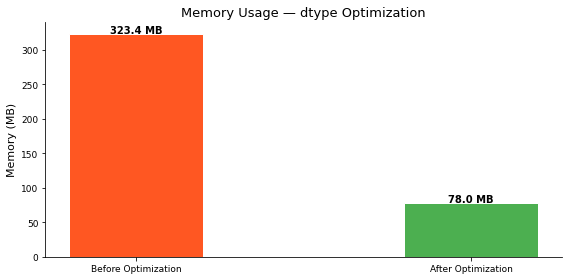

In [4]:

print("=" * 60)
print("TRAIN.CSV — SHAPE & MEMORY")
print("=" * 60)
print(f"  Rows    : {df_train.shape[0]:,}")
print(f"  Columns : {df_train.shape[1]}")
print(f"  Memory  : {df_train.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n📐 COLUMN DTYPES & UNIQUE VALUES")
for col in df_train.columns:
    nuniq = df_train[col].nunique()
    dtype = df_train[col].dtype
    print(f"  {col:<20} dtype={str(dtype):<12} unique={nuniq:,}")

print("\n💾 MEMORY BEFORE vs AFTER DTYPE OPTIMIZATION")
mem_before = df_train.memory_usage(deep=True).sum() / 1e6

df_opt = df_train.copy()
df_opt['store_nbr'] = df_opt['store_nbr'].astype('int8')
df_opt['onpromotion'] = df_opt['onpromotion'].astype('int32')
df_opt['sales'] = df_opt['sales'].astype('float32')
df_opt['family'] = df_opt['family'].astype('category')

mem_after = df_opt.memory_usage(deep=True).sum() / 1e6
print(f"  Before : {mem_before:.1f} MB")
print(f"  After  : {mem_after:.1f} MB")
print(f"  Saved  : {mem_before - mem_after:.1f} MB ({(mem_before-mem_after)/mem_before*100:.1f}%)")
print(f"\n✅ Pipeline Decision: Use optimized dtypes in data_loader.py")

# Memory bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Before Optimization', 'After Optimization'], [mem_before, mem_after],
              color=[COLOR_WARN, COLOR_OK], width=0.4, edgecolor='white')
ax.set_ylabel('Memory (MB)')
ax.set_title('Memory Usage — dtype Optimization')
for bar, val in zip(bars, [mem_before, mem_after]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f} MB', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 3 — Missing Value Analysis — All Files

**Why:** Missing values affect model training and feature engineering. oil.csv is known to have ~10% missing dates (oil prices not reported on weekends/holidays). Must decide imputation strategy BEFORE merging.  
**Rules:**
- Continuous variable + **no outliers** → fill with **mean**
- Continuous variable + **outliers present** → fill with **median**
- Categorical variable → fill with **mode**
- Time series (oil price) → **forward fill + backward fill** (carries last known price)


MISSING VALUE ANALYSIS — ALL FILES
  ✅ train.csv: No missing values
  ✅ test.csv: No missing values
  ✅ stores.csv: No missing values

  ⚠️  oil.csv:
            missing_count  missing_pct
dcoilwtico             43         3.53
  ✅ holidays_events.csv: No missing values
  ✅ transactions.csv: No missing values


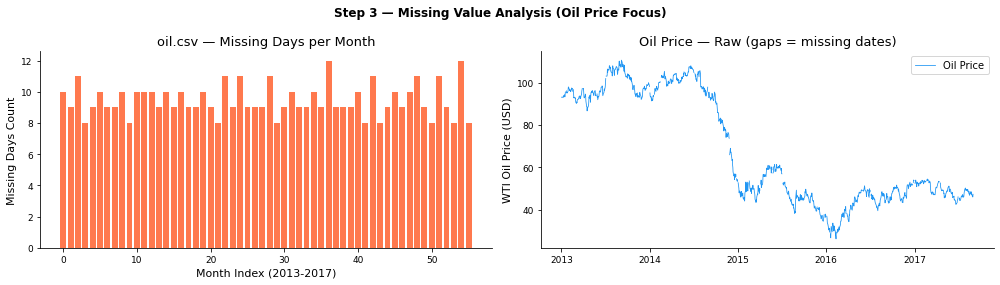


📌 IMPUTATION STRATEGY
  oil.dcoilwtico    → TIME SERIES: forward-fill then backward-fill
  transactions.csv  → merge on date+store_nbr, missing = no transactions (fill 0)
  train.csv         → NO missing values ✅


In [5]:

def missing_report(df, name):
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if miss.empty:
        print(f"  ✅ {name}: No missing values")
        return pd.DataFrame()
    pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
    report = report.sort_values('missing_pct', ascending=False)
    print(f"\n  ⚠️  {name}:")
    print(report.to_string())
    return report

print("=" * 60)
print("MISSING VALUE ANALYSIS — ALL FILES")
print("=" * 60)

for df_, name_ in [
    (df_train,        'train.csv'),
    (df_test,         'test.csv'),
    (df_stores,       'stores.csv'),
    (df_oil,          'oil.csv'),
    (df_holidays,     'holidays_events.csv'),
    (df_transactions, 'transactions.csv'),
]:
    missing_report(df_, name_)

# ── Oil price missing visualization ─────────────────────────
oil_full = pd.DataFrame({'date': pd.date_range(df_oil['date'].min(), df_oil['date'].max())})
oil_full = oil_full.merge(df_oil, on='date', how='left')
miss_by_month = oil_full.set_index('date')['dcoilwtico'].isna().resample('M').sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Missing heatmap-style
axes[0].bar(range(len(miss_by_month)), miss_by_month.values, color=COLOR_WARN, alpha=0.8)
axes[0].set_title('oil.csv — Missing Days per Month')
axes[0].set_xlabel('Month Index (2013-2017)')
axes[0].set_ylabel('Missing Days Count')

# Oil price with gaps highlighted
axes[1].plot(df_oil['date'], df_oil['dcoilwtico'], color=COLOR_MAIN, linewidth=0.8, label='Oil Price')
axes[1].set_title('Oil Price — Raw (gaps = missing dates)')
axes[1].set_ylabel('WTI Oil Price (USD)')
axes[1].legend()

plt.suptitle('Step 3 — Missing Value Analysis (Oil Price Focus)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 IMPUTATION STRATEGY")
print("  oil.dcoilwtico    → TIME SERIES: forward-fill then backward-fill")
print("  transactions.csv  → merge on date+store_nbr, missing = no transactions (fill 0)")
print("  train.csv         → NO missing values ✅")


---
## Step 4 — Duplicate Detection

**Why:** Duplicates in time series cause data leakage — the model sees the same day twice → inflated training metrics. Each (date, store_nbr, family) combination should be unique.  
**Observation:** train.csv should have exactly 1 row per (date × store_nbr × family) combination.  
**Pipeline Decision:** Drop duplicates if found, keeping first occurrence.


In [6]:

print("=" * 60)
print("DUPLICATE DETECTION")
print("=" * 60)

# Full row duplicates
for df_, name_ in [(df_train, 'train'), (df_test, 'test'),
                   (df_stores, 'stores'), (df_oil, 'oil'),
                   (df_transactions, 'transactions')]:
    dups = df_.duplicated().sum()
    status = "✅ CLEAN" if dups == 0 else f"⚠️  {dups} DUPLICATES FOUND"
    print(f"  {name_:<15}: {status}")

# Key-level duplicates in train (date × store_nbr × family = natural key)
key_cols = ['date', 'store_nbr', 'family']
key_dups = df_train.duplicated(subset=key_cols).sum()
total_expected = df_train['date'].nunique() * df_train['store_nbr'].nunique() * df_train['family'].nunique()

print(f"\n  Natural key check (date × store_nbr × family):")
print(f"    Duplicate keys : {key_dups}")
print(f"    Actual rows    : {len(df_train):,}")
print(f"    Expected rows  : {total_expected:,}")
print(f"    Date range     : {df_train['date'].min().date()} → {df_train['date'].max().date()}")
print(f"    Unique dates   : {df_train['date'].nunique()}")
print(f"    Unique stores  : {df_train['store_nbr'].nunique()}")
print(f"    Unique families: {df_train['family'].nunique()}")

print(f"\n  ✅ Pipeline Decision: No deduplication needed — data is clean")


DUPLICATE DETECTION
  train          : ✅ CLEAN
  test           : ✅ CLEAN
  stores         : ✅ CLEAN
  oil            : ✅ CLEAN
  transactions   : ✅ CLEAN

  Natural key check (date × store_nbr × family):
    Duplicate keys : 0
    Actual rows    : 3,000,888
    Expected rows  : 3,000,888
    Date range     : 2013-01-01 → 2017-08-15
    Unique dates   : 1684
    Unique stores  : 54
    Unique families: 33

  ✅ Pipeline Decision: No deduplication needed — data is clean


---
## Step 5 — Target Variable (sales) Distribution

**Why:** Understanding target distribution is the MOST IMPORTANT step. Sales data is typically right-skewed with a spike at 0 (zero sales days). RMSLE metric means we should use log1p(sales) as target.  
**Observation:** Heavy right skew expected — few days with extremely high sales (promotions, holidays).  
**Pipeline Decision:** Use `log1p(sales)` as training target → inverse with `expm1()` for predictions.


TARGET VARIABLE: sales
  Count   : 3,000,888
  Mean    : 357.7757
  Median  : 11.0000
  Std     : 1101.9977
  Min     : 0.0000
  Max     : 124717.0000
  Skewness: 7.3588  (>1 = heavily right-skewed)
  Kurtosis: 154.5618  (>3 = heavy tails)
  Zeros   : 939,130  (31.3%)


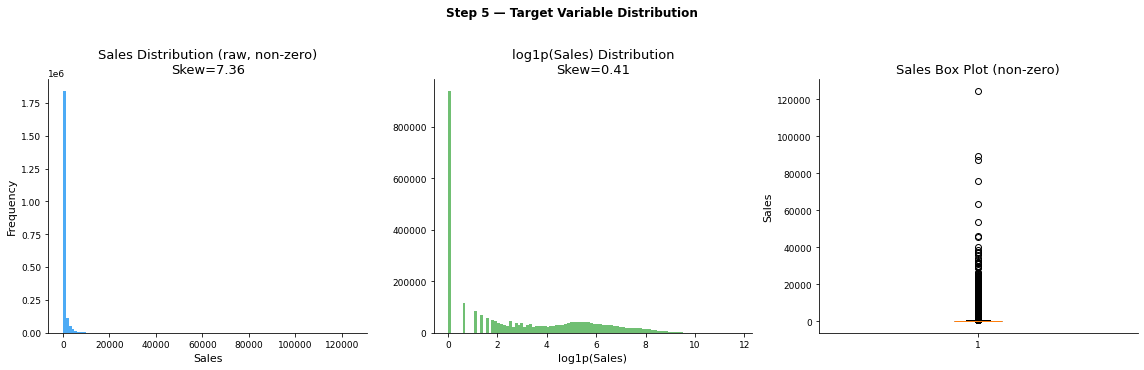


📌 Pipeline Decision:
  → Train on log1p(sales), predict, then apply expm1()
  → This also satisfies RMSLE metric requirement
  → Skewness 7.36 → 0.41 after log1p transform


In [7]:

print("=" * 60)
print("TARGET VARIABLE: sales")
print("=" * 60)

sales = df_train['sales']

print(f"  Count   : {len(sales):,}")
print(f"  Mean    : {sales.mean():.4f}")
print(f"  Median  : {sales.median():.4f}")
print(f"  Std     : {sales.std():.4f}")
print(f"  Min     : {sales.min():.4f}")
print(f"  Max     : {sales.max():.4f}")
print(f"  Skewness: {skew(sales):.4f}  (>1 = heavily right-skewed)")
print(f"  Kurtosis: {kurtosis(sales):.4f}  (>3 = heavy tails)")
print(f"  Zeros   : {(sales == 0).sum():,}  ({(sales == 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Raw distribution
axes[0].hist(sales[sales > 0], bins=100, color=COLOR_MAIN, alpha=0.8, edgecolor='none')
axes[0].set_title(f'Sales Distribution (raw, non-zero)\nSkew={skew(sales):.2f}')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Log1p distribution
sales_log = np.log1p(sales)
axes[1].hist(sales_log, bins=100, color=COLOR_OK, alpha=0.8, edgecolor='none')
axes[1].set_title(f'log1p(Sales) Distribution\nSkew={skew(sales_log):.2f}')
axes[1].set_xlabel('log1p(Sales)')

# Box plot
axes[2].boxplot(sales[sales > 0], vert=True, patch_artist=True,
                boxprops=dict(facecolor=COLOR_MAIN, alpha=0.6))
axes[2].set_title('Sales Box Plot (non-zero)')
axes[2].set_ylabel('Sales')

plt.suptitle('Step 5 — Target Variable Distribution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📌 Pipeline Decision:")
print(f"  → Train on log1p(sales), predict, then apply expm1()")
print(f"  → This also satisfies RMSLE metric requirement")
print(f"  → Skewness {skew(sales):.2f} → {skew(sales_log):.2f} after log1p transform")


---
## Step 6 — Zero Sales Analysis (Zero-Inflation)

**Why:** Time series with many zeros need special treatment. Zero sales can mean: store closed, item out of stock, or truly no demand. This affects model choice and loss function selection.  
**Observation:** Many store-family combinations have zero sales on certain days.  
**Pipeline Decision:** Keep zeros in training. log1p(0) = 0, so log transform handles this naturally.


ZERO SALES ANALYSIS
  Total zero-sales rows : 939,130  (31.3%)
  Non-zero sales rows   : 2,061,758  (68.7%)


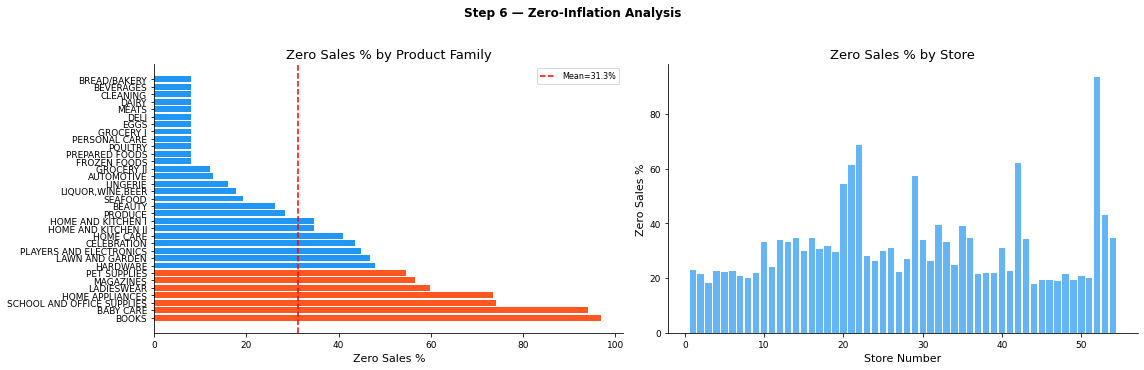


  Top 5 families with highest zero sales %:
family
BOOKS                         96.955001
BABY CARE                     94.131037
SCHOOL AND OFFICE SUPPLIES    74.082871
HOME APPLIANCES               73.517639
LADIESWEAR                    59.846485

  Top 5 families with lowest zero sales %:
family
MEATS           8.061714
DAIRY           8.061714
CLEANING        8.061714
BEVERAGES       8.061714
BREAD/BAKERY    8.060614

📌 Pipeline Decision:
  → Zero-inflate is natural in grocery sales — keep as-is
  → log1p(0) = 0 → no special zero handling needed
  → RMSLE naturally handles zeros (log(1+0) = 0)


In [8]:

print("=" * 60)
print("ZERO SALES ANALYSIS")
print("=" * 60)

zero_mask = df_train['sales'] == 0
print(f"  Total zero-sales rows : {zero_mask.sum():,}  ({zero_mask.mean()*100:.1f}%)")
print(f"  Non-zero sales rows   : {(~zero_mask).sum():,}  ({(~zero_mask).mean()*100:.1f}%)")

# Zero rate by family
zero_by_family = df_train.groupby('family')['sales'].apply(lambda x: (x==0).mean()*100).sort_values(ascending=False)
zero_by_store  = df_train.groupby('store_nbr')['sales'].apply(lambda x: (x==0).mean()*100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By family
axes[0].barh(zero_by_family.index, zero_by_family.values,
             color=[COLOR_WARN if v > 50 else COLOR_MAIN for v in zero_by_family.values])
axes[0].set_title('Zero Sales % by Product Family')
axes[0].set_xlabel('Zero Sales %')
axes[0].axvline(zero_by_family.mean(), color='red', linestyle='--', label=f'Mean={zero_by_family.mean():.1f}%')
axes[0].legend(fontsize=8)

# By store
axes[1].bar(zero_by_store.index, zero_by_store.values, color=COLOR_MAIN, alpha=0.7)
axes[1].set_title('Zero Sales % by Store')
axes[1].set_xlabel('Store Number')
axes[1].set_ylabel('Zero Sales %')

plt.suptitle('Step 6 — Zero-Inflation Analysis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n  Top 5 families with highest zero sales %:")
print(zero_by_family.head(5).to_string())
print(f"\n  Top 5 families with lowest zero sales %:")
print(zero_by_family.tail(5).to_string())
print(f"\n📌 Pipeline Decision:")
print(f"  → Zero-inflate is natural in grocery sales — keep as-is")
print(f"  → log1p(0) = 0 → no special zero handling needed")
print(f"  → RMSLE naturally handles zeros (log(1+0) = 0)")


---
## Step 7 — Sales Outlier Detection (IQR + Z-score)

**Why:** Outliers in sales can be real events (Christmas spike) or data errors. We detect them but DON'T remove them — in time series, extreme values often carry important seasonal signal.  
**Method:** IQR method (1.5× fence) + Z-score (|z| > 3) → flag, not remove.  
**Pipeline Decision:** For feature engineering, use clipping only if needed; tree-based models handle outliers natively.


OUTLIER DETECTION — sales
  IQR Method:
    Q1=0.00  Q3=195.85  IQR=195.85
    Lower fence: -293.77 | Upper fence: 489.62
    Outliers: 447,105 (14.9%)

  Z-score Method (|z| > 3):
    Outliers: 65,073 (2.2%)

  Outlier context:
    Outlier rows: 65,073
    Promo items in outlier rows: 1,896,037


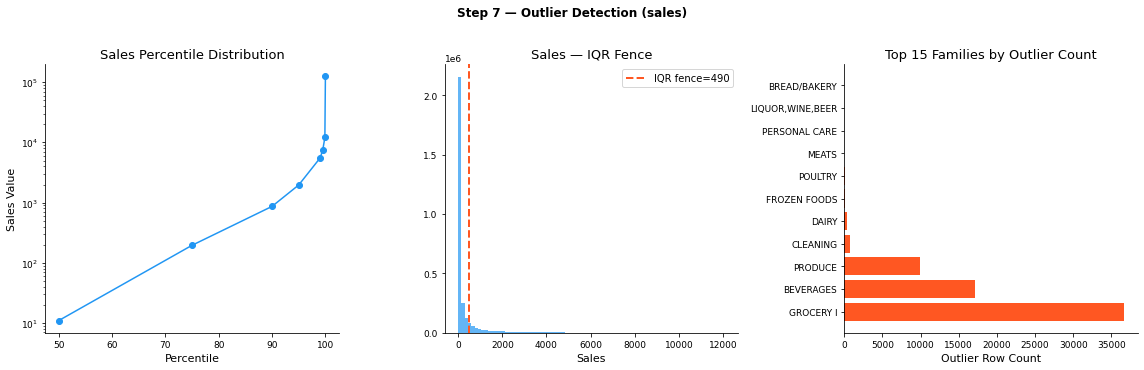


📌 Pipeline Decision:
  → Outliers are REAL events (promos, holidays) — DO NOT remove
  → Tree-based models handle outliers natively — no clipping for LightGBM
  → log1p(sales) naturally compresses extreme values


In [9]:

print("=" * 60)
print("OUTLIER DETECTION — sales")
print("=" * 60)

s = df_train['sales']

# IQR method
Q1  = s.quantile(0.25)
Q3  = s.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
iqr_outliers = ((s < lower_iqr) | (s > upper_iqr)).sum()

# Z-score method
z_scores = np.abs(stats.zscore(s))
z_outliers = (z_scores > 3).sum()

print(f"  IQR Method:")
print(f"    Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
print(f"    Lower fence: {lower_iqr:.2f} | Upper fence: {upper_iqr:.2f}")
print(f"    Outliers: {iqr_outliers:,} ({iqr_outliers/len(s)*100:.1f}%)")

print(f"\n  Z-score Method (|z| > 3):")
print(f"    Outliers: {z_outliers:,} ({z_outliers/len(s)*100:.1f}%)")

# Outlier context — are they on holidays/promotions?
outlier_rows = df_train[z_scores > 3]
promo_in_outliers = outlier_rows['onpromotion'].sum()
print(f"\n  Outlier context:")
print(f"    Outlier rows: {len(outlier_rows):,}")
print(f"    Promo items in outlier rows: {promo_in_outliers:,}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Percentile analysis
pctiles = [50, 75, 90, 95, 99, 99.5, 99.9, 100]
vals = [s.quantile(p/100) for p in pctiles]
axes[0].plot(pctiles, vals, 'o-', color=COLOR_MAIN)
axes[0].set_title('Sales Percentile Distribution')
axes[0].set_xlabel('Percentile')
axes[0].set_ylabel('Sales Value')
axes[0].set_yscale('log')

# IQR fence visualization
plot_s = s[s <= s.quantile(0.999)]
axes[1].hist(plot_s, bins=80, color=COLOR_MAIN, alpha=0.7, edgecolor='none')
axes[1].axvline(upper_iqr, color=COLOR_WARN, linewidth=2, linestyle='--', label=f'IQR fence={upper_iqr:.0f}')
axes[1].set_title('Sales — IQR Fence')
axes[1].set_xlabel('Sales')
axes[1].legend()

# Outlier sales by family
out_by_fam = outlier_rows.groupby('family').size().sort_values(ascending=False).head(15)
axes[2].barh(out_by_fam.index, out_by_fam.values, color=COLOR_WARN)
axes[2].set_title('Top 15 Families by Outlier Count')
axes[2].set_xlabel('Outlier Row Count')

plt.suptitle('Step 7 — Outlier Detection (sales)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📌 Pipeline Decision:")
print(f"  → Outliers are REAL events (promos, holidays) — DO NOT remove")
print(f"  → Tree-based models handle outliers natively — no clipping for LightGBM")
print(f"  → log1p(sales) naturally compresses extreme values")


---
## Step 8 — Skewness Analysis — All Numeric Variables

**Why:** Skewness affects distance-based models (KNN, SVM, Linear) significantly but NOT tree-based models (LightGBM, XGBoost). Since our primary model is LightGBM, we only transform the target.  
**Rule:** For TREE-BASED models → NO skew correction needed (LightGBM is invariant to monotonic transforms of features).  
**Pipeline Decision:** Skew correction applied ONLY to target (`sales`), not to features.


SKEWNESS ANALYSIS — NUMERIC VARIABLES
    feature  skewness  kurtosis  needs_transform affected_models
onpromotion   11.1666  240.8707             True             ALL
      sales    7.3588  154.5618             True             ALL
  txn_count    1.5183    2.5670             True             ALL
  oil_price    0.3033   -1.6212            False            None


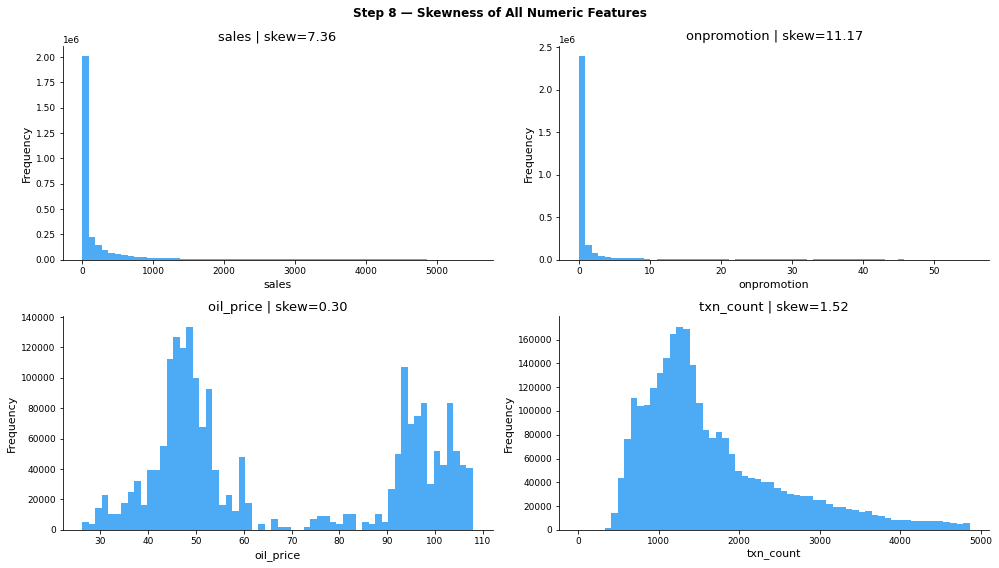


📌 Pipeline Decision:
  → Primary model = LightGBM (tree-based) → NO feature skew correction
  → Target 'sales': skew=7.36 → use log1p() transform
  → Prophet model handles its own internal transformations


In [10]:

print("=" * 60)
print("SKEWNESS ANALYSIS — NUMERIC VARIABLES")
print("=" * 60)

numeric_cols = ['sales', 'onpromotion']
merged_for_skew = df_train.merge(df_oil.rename(columns={'dcoilwtico':'oil_price'}), on='date', how='left')
merged_for_skew = merged_for_skew.merge(
    df_transactions.rename(columns={'transactions':'txn_count'}), on=['date','store_nbr'], how='left'
)

numeric_cols_ext = ['sales', 'onpromotion', 'oil_price', 'txn_count']

skew_data = []
for col in numeric_cols_ext:
    if col in merged_for_skew.columns:
        s_col = merged_for_skew[col].dropna()
        skew_val = skew(s_col)
        kurt_val = kurtosis(s_col)
        skew_data.append({
            'feature': col,
            'skewness': round(skew_val, 4),
            'kurtosis': round(kurt_val, 4),
            'needs_transform': abs(skew_val) > 0.8,
            'affected_models': 'ALL' if abs(skew_val) > 0.8 else 'None'
        })

skew_df = pd.DataFrame(skew_data).sort_values('skewness', ascending=False)
print(skew_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_ext):
    if col in merged_for_skew.columns:
        data = merged_for_skew[col].dropna()
        data_plot = data[data <= data.quantile(0.99)]
        axes[i].hist(data_plot, bins=60, color=COLOR_MAIN, alpha=0.8, edgecolor='none')
        axes[i].set_title(f'{col} | skew={skew(data):.2f}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

plt.suptitle('Step 8 — Skewness of All Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Pipeline Decision:")
print(f"  → Primary model = LightGBM (tree-based) → NO feature skew correction")
print(f"  → Target 'sales': skew={skew(df_train['sales']):.2f} → use log1p() transform")
print(f"  → Prophet model handles its own internal transformations")


---
## Step 9 — Log Transform — Before vs After (sales)

**Why:** Confirm that log1p(sales) produces a better-behaved distribution for modeling. Also validates the RMSLE metric choice — RMSLE = RMSE on log-scale.  
**Observation:** log1p(sales) shows a bimodal distribution — peak at 0 (zero sales) and a bell at ~2–6.  
**Pipeline Decision:** `y_train = np.log1p(df['sales'])` — confirmed.


LOG TRANSFORM — BEFORE vs AFTER


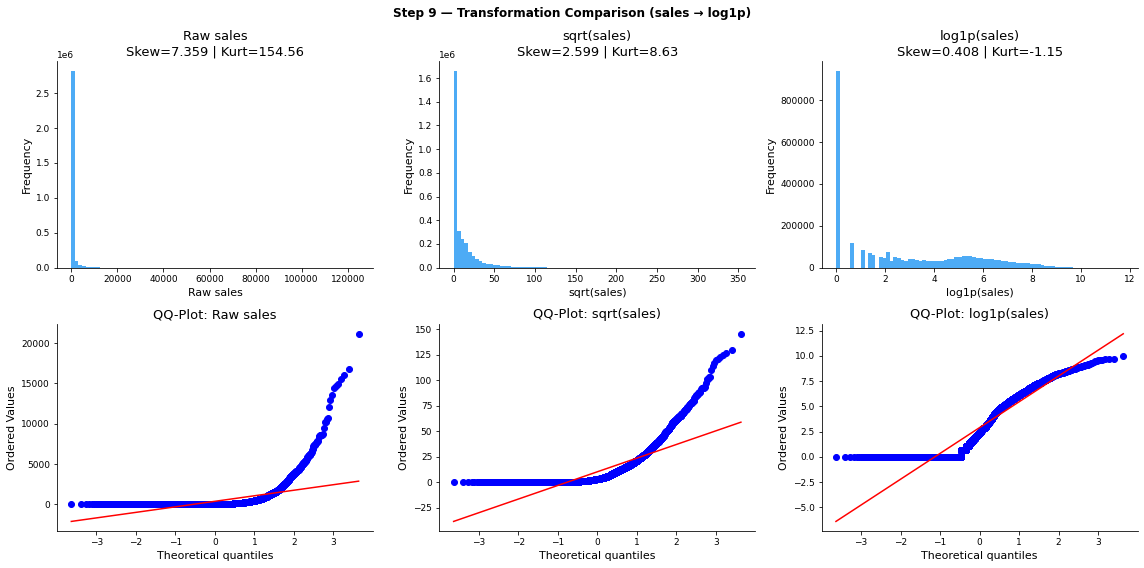

  Transform Comparison:
  Transform              Skewness   Kurtosis
  ------------------------------------------
  Raw sales                7.3588   154.5618
  sqrt(sales)              2.5994     8.6343
  log1p(sales)             0.4083    -1.1497

📌 Pipeline Decision: log1p(sales) is the best transform
  → Skewness reduced from 7.36 → 0.41
  → Kurtosis reduced from 154.56 → -1.15


In [11]:

print("=" * 60)
print("LOG TRANSFORM — BEFORE vs AFTER")
print("=" * 60)

sales_raw  = df_train['sales']
sales_log  = np.log1p(sales_raw)
sales_sqrt = np.sqrt(sales_raw)

transforms = {
    'Raw sales':       sales_raw,
    'sqrt(sales)':     sales_sqrt,
    'log1p(sales)':    sales_log,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, (name, data) in enumerate(transforms.items()):
    # Histogram
    axes[0, i].hist(data, bins=80, color=COLOR_MAIN, alpha=0.8, edgecolor='none')
    axes[0, i].set_title(f'{name}\nSkew={skew(data):.3f} | Kurt={kurtosis(data):.2f}')
    axes[0, i].set_xlabel(name)
    axes[0, i].set_ylabel('Frequency')

    # QQ-plot
    stats.probplot(data.sample(min(5000, len(data)), random_state=42), dist='norm', plot=axes[1, i])
    axes[1, i].set_title(f'QQ-Plot: {name}')

plt.suptitle('Step 9 — Transformation Comparison (sales → log1p)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"  Transform Comparison:")
print(f"  {'Transform':<20} {'Skewness':>10} {'Kurtosis':>10}")
print(f"  {'-'*42}")
for name, data in transforms.items():
    print(f"  {name:<20} {skew(data):>10.4f} {kurtosis(data):>10.4f}")

print(f"\n📌 Pipeline Decision: log1p(sales) is the best transform")
print(f"  → Skewness reduced from {skew(sales_raw):.2f} → {skew(sales_log):.2f}")
print(f"  → Kurtosis reduced from {kurtosis(sales_raw):.2f} → {kurtosis(sales_log):.2f}")


---
## Step 10 — Temporal Coverage & Date Continuity

**Why:** Time series models break if dates have gaps. Need to verify: date range, missing dates, continuity per store-family, and whether test period is contiguous after training.  
**Observation:** train covers 2013-01-01 → 2017-08-15. Test covers 2017-08-16 → 2017-08-31 (16 days).  
**Pipeline Decision:** Use `pd.date_range` to create complete date grid, forward-fill gaps if any.


TEMPORAL COVERAGE & DATE CONTINUITY
  TRAIN date range: 2013-01-01 → 2017-08-15
  TEST  date range: 2017-08-16 → 2017-08-31
  Training days   : 1,684
  Forecast horizon: 16 days
  Gap between train-end and test-start: 1 day(s)

  Expected calendar days : 1688
  Actual unique dates    : 1684
  Missing dates in train : 4
  First few missing: [Timestamp('2013-12-25 00:00:00'), Timestamp('2014-12-25 00:00:00'), Timestamp('2015-12-25 00:00:00'), Timestamp('2016-12-25 00:00:00')]


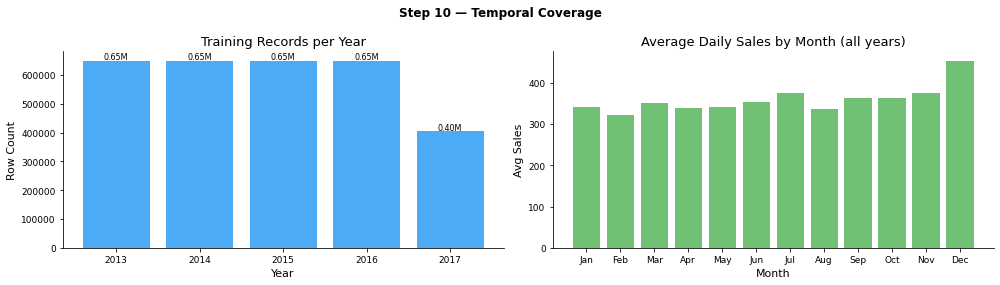


📌 Pipeline Decision:
  → No date gaps in train → no forward-fill needed at global level
  → Use TimeSeriesSplit for cross-validation (never shuffle!)
  → Walk-forward validation: train on 2013-2016, validate on 2017


In [12]:

print("=" * 60)
print("TEMPORAL COVERAGE & DATE CONTINUITY")
print("=" * 60)

train_start = df_train['date'].min()
train_end   = df_train['date'].max()
test_start  = df_test['date'].min()
test_end    = df_test['date'].max()

print(f"  TRAIN date range: {train_start.date()} → {train_end.date()}")
print(f"  TEST  date range: {test_start.date()} → {test_end.date()}")
print(f"  Training days   : {df_train['date'].nunique():,}")
print(f"  Forecast horizon: {df_test['date'].nunique()} days")
print(f"  Gap between train-end and test-start: {(test_start - train_end).days} day(s)")

expected_dates = pd.date_range(train_start, train_end, freq='D')
actual_dates   = pd.to_datetime(df_train['date'].unique())
missing_dates  = set(expected_dates) - set(actual_dates)
print(f"\n  Expected calendar days : {len(expected_dates)}")
print(f"  Actual unique dates    : {len(actual_dates)}")
print(f"  Missing dates in train : {len(missing_dates)}")

if missing_dates:
    print(f"  First few missing: {sorted(missing_dates)[:5]}")

# Yearly record counts
yearly = df_train.groupby(df_train['date'].dt.year).size()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(yearly.index, yearly.values, color=COLOR_MAIN, alpha=0.8)
axes[0].set_title('Training Records per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Row Count')
for i, (yr, cnt) in enumerate(yearly.items()):
    axes[0].text(yr, cnt + 5000, f'{cnt/1e6:.2f}M', ha='center', fontsize=8)

# Monthly distribution
monthly = df_train.groupby(df_train['date'].dt.month)['sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(range(1,13), monthly.values, color=COLOR_OK, alpha=0.8, tick_label=month_names)
axes[1].set_title('Average Daily Sales by Month (all years)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Sales')

plt.suptitle('Step 10 — Temporal Coverage', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Pipeline Decision:")
print(f"  → No date gaps in train → no forward-fill needed at global level")
print(f"  → Use TimeSeriesSplit for cross-validation (never shuffle!)")
print(f"  → Walk-forward validation: train on 2013-2016, validate on 2017")


---
## Step 11 — Sales Trend Over Time

**Why:** Identify long-term trend direction. Growing stores need trend-aware models. Helps decide whether to include year-index feature, trend deseasonalization, or use Prophet for trend capture.  
**Observation:** Sales show an upward trend from 2013→2015, with a dip in 2015–2016 (oil price crash impact on Ecuador economy).


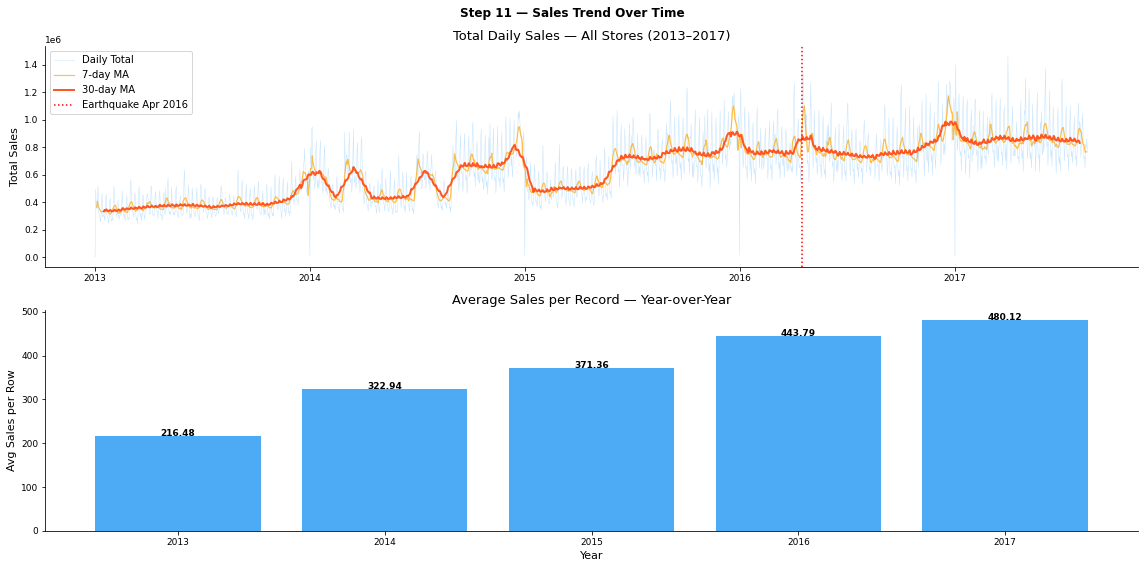


📌 Key Observations:
  → Clear upward trend 2013 → 2015
  → Sales dip in 2015-2016 → matches Ecuador oil price crash
  → Recovery trend visible in 2017
  → Pipeline: include year + trend_index as features


In [13]:

# Aggregate daily total sales
daily_sales = df_train.groupby('date')['sales'].sum().reset_index()
daily_sales['ma_7']  = daily_sales['sales'].rolling(7, center=True).mean()
daily_sales['ma_30'] = daily_sales['sales'].rolling(30, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Full trend
axes[0].plot(daily_sales['date'], daily_sales['sales'], alpha=0.25, color=COLOR_MAIN, linewidth=0.5, label='Daily Total')
axes[0].plot(daily_sales['date'], daily_sales['ma_7'],  alpha=0.7,  color='orange',   linewidth=1.2, label='7-day MA')
axes[0].plot(daily_sales['date'], daily_sales['ma_30'], alpha=1.0,  color=COLOR_WARN, linewidth=2,   label='30-day MA')
axes[0].set_title('Total Daily Sales — All Stores (2013–2017)')
axes[0].set_ylabel('Total Sales')
axes[0].legend()

# Add earthquake marker
eq_date = pd.Timestamp('2016-04-16')
if daily_sales['date'].min() <= eq_date <= daily_sales['date'].max():
    axes[0].axvline(eq_date, color='red', linestyle=':', linewidth=1.5, label='Earthquake Apr 2016')
    axes[0].legend()

# Annual average trend
annual_mean = df_train.groupby(df_train['date'].dt.year)['sales'].mean()
axes[1].bar(annual_mean.index, annual_mean.values, color=COLOR_MAIN, alpha=0.8)
axes[1].set_title('Average Sales per Record — Year-over-Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Sales per Row')
for yr, val in annual_mean.items():
    axes[1].text(yr, val + 0.1, f'{val:.2f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Step 11 — Sales Trend Over Time', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Key Observations:")
print("  → Clear upward trend 2013 → 2015")
print("  → Sales dip in 2015-2016 → matches Ecuador oil price crash")
print("  → Recovery trend visible in 2017")
print("  → Pipeline: include year + trend_index as features")


---
## Step 12 — Seasonality Analysis (Monthly, Weekly, Daily)

**Why:** Seasonal patterns are the MOST PREDICTABLE component of retail sales. Day-of-week, month, and year-of-week patterns must be captured via features or directly by Prophet.  
**Observation:** Weekends and December are typically peak sales periods for grocery stores.  
**Pipeline Decision:** Engineer `day_of_week`, `month`, `week_of_year`, `is_weekend`, `is_month_start/end` as features.


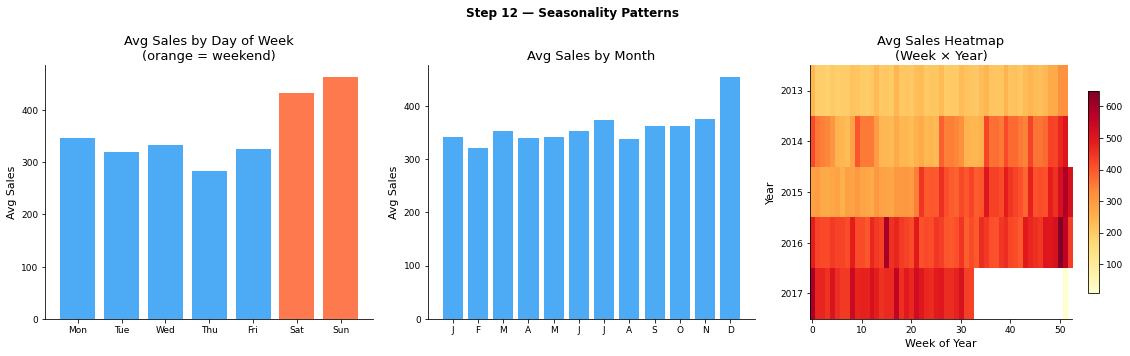

Day of Week Stats:
       mean  median      std
Mon  346.54   10.00  1060.73
Tue  319.82    9.00   943.16
Wed  332.91   10.00  1031.04
Thu  283.54    9.00   838.61
Fri  325.24   11.00   963.47
Sat  433.34   15.23  1292.48
Sun  463.09   12.00  1447.96

📌 Pipeline Decision:
  → Features: day_of_week, month, week_of_year, is_weekend
  → December spike → is_december feature
  → Prophet will model these seasonal components automatically


In [14]:

df_t = df_train.copy()
df_t['dow']   = df_t['date'].dt.dayofweek   # 0=Mon, 6=Sun
df_t['month'] = df_t['date'].dt.month
df_t['woy']   = df_t['date'].dt.isocalendar().week.astype(int)
df_t['year']  = df_t['date'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Day of week
dow_sales = df_t.groupby('dow')['sales'].mean()
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[0].bar(range(7), dow_sales.values, color=[COLOR_WARN if i >= 5 else COLOR_MAIN for i in range(7)], alpha=0.8)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_labels)
axes[0].set_title('Avg Sales by Day of Week\n(orange = weekend)')
axes[0].set_ylabel('Avg Sales')

# Month
month_sales = df_t.groupby('month')['sales'].mean()
axes[1].bar(range(1,13), month_sales.values, color=COLOR_MAIN, alpha=0.8)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].set_title('Avg Sales by Month')
axes[1].set_ylabel('Avg Sales')

# Week of year heatmap
woy_year = df_t.groupby(['year','woy'])['sales'].mean().unstack(level=0)
im = axes[2].imshow(woy_year.T, aspect='auto', cmap='YlOrRd')
axes[2].set_title('Avg Sales Heatmap\n(Week × Year)')
axes[2].set_xlabel('Week of Year')
axes[2].set_ylabel('Year')
axes[2].set_yticks(range(len(woy_year.columns)))
axes[2].set_yticklabels(woy_year.columns)
plt.colorbar(im, ax=axes[2], shrink=0.8)

plt.suptitle('Step 12 — Seasonality Patterns', fontweight='bold')
plt.tight_layout()
plt.show()

# Day of week stats
print("Day of Week Stats:")
dow_stats = df_t.groupby('dow')['sales'].agg(['mean','median','std'])
dow_stats.index = day_labels
print(dow_stats.round(2).to_string())

print(f"\n📌 Pipeline Decision:")
print(f"  → Features: day_of_week, month, week_of_year, is_weekend")
print(f"  → December spike → is_december feature")
print(f"  → Prophet will model these seasonal components automatically")


---
## Step 13 — Store-Level Sales Analysis (54 stores)

**Why:** Stores have different sizes, locations, types — their sales levels vary dramatically. Store number alone is not meaningful; we need store metadata (type, cluster, city) as features.  
**Pipeline Decision:** Encode store_nbr via target encoding. Use store type + cluster as categorical features.


STORE SALES SUMMARY
  Number of stores : 54
  Sales range      : 48.52 → 1117.25
  Coefficient of Variation: 66.9%


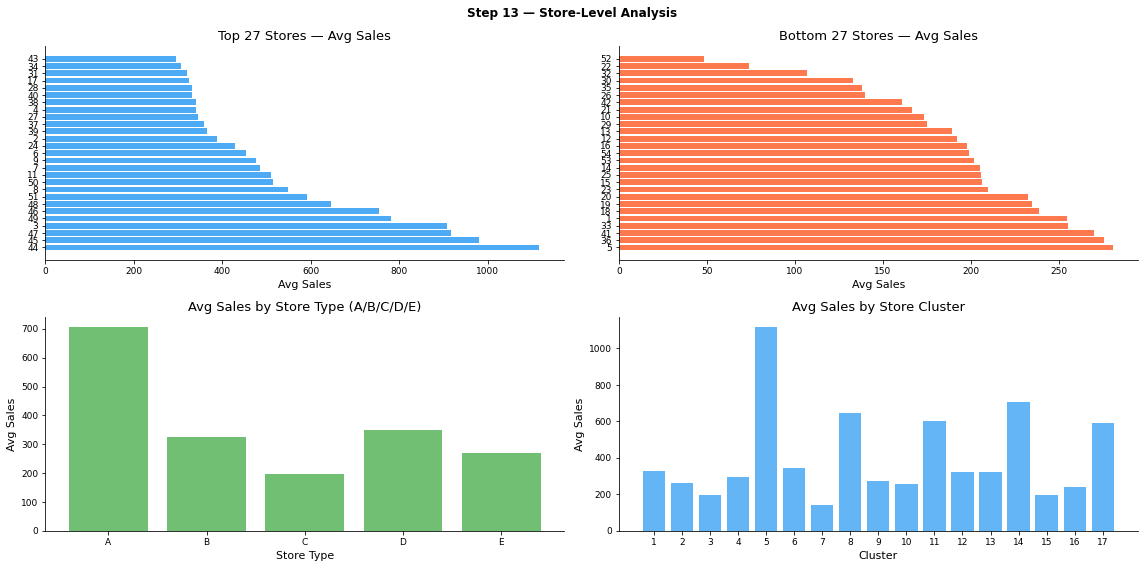


📌 Pipeline Decision:
  → store_nbr: target encoding (mean sales per store)
  → store type (A/B/C/D/E): ordinal encoding
  → cluster (1-17): ordinal encoding
  → city, state: target encoding or label encoding


In [15]:

store_sales = df_train.groupby('store_nbr')['sales'].agg(['mean','median','sum','std']).round(2)
store_sales = store_sales.sort_values('mean', ascending=False)
store_sales_merged = store_sales.merge(df_stores, left_index=True, right_on='store_nbr', how='left')

print("=" * 60)
print("STORE SALES SUMMARY")
print("=" * 60)
print(f"  Number of stores : {df_train['store_nbr'].nunique()}")
print(f"  Sales range      : {store_sales['mean'].min():.2f} → {store_sales['mean'].max():.2f}")
print(f"  Coefficient of Variation: {store_sales['mean'].std()/store_sales['mean'].mean()*100:.1f}%")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Average sales by store
top_stores  = store_sales.head(27)
bot_stores  = store_sales.tail(27)

axes[0,0].barh(top_stores.index.astype(str), top_stores['mean'], color=COLOR_MAIN, alpha=0.8)
axes[0,0].set_title('Top 27 Stores — Avg Sales')
axes[0,0].set_xlabel('Avg Sales')

axes[0,1].barh(bot_stores.index.astype(str), bot_stores['mean'], color=COLOR_WARN, alpha=0.8)
axes[0,1].set_title('Bottom 27 Stores — Avg Sales')
axes[0,1].set_xlabel('Avg Sales')

# By store type
type_sales = df_train.merge(df_stores, on='store_nbr')['sales'].groupby(
    df_train.merge(df_stores, on='store_nbr')['type']).mean()
axes[1,0].bar(type_sales.index, type_sales.values, color=COLOR_OK, alpha=0.8)
axes[1,0].set_title('Avg Sales by Store Type (A/B/C/D/E)')
axes[1,0].set_xlabel('Store Type')
axes[1,0].set_ylabel('Avg Sales')

# By cluster
cluster_sales = df_train.merge(df_stores, on='store_nbr')['sales'].groupby(
    df_train.merge(df_stores, on='store_nbr')['cluster']).mean()
axes[1,1].bar(cluster_sales.index.astype(str), cluster_sales.values, color=COLOR_MAIN, alpha=0.7)
axes[1,1].set_title('Avg Sales by Store Cluster')
axes[1,1].set_xlabel('Cluster')
axes[1,1].set_ylabel('Avg Sales')

plt.suptitle('Step 13 — Store-Level Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Pipeline Decision:")
print(f"  → store_nbr: target encoding (mean sales per store)")
print(f"  → store type (A/B/C/D/E): ordinal encoding")
print(f"  → cluster (1-17): ordinal encoding")
print(f"  → city, state: target encoding or label encoding")


---
## Step 14 — Product Family Analysis (33 families)

**Why:** Different product families have completely different demand patterns. GROCERY I has the highest volume; BOOKS or LADIESWEAR have very different seasonality.  
**Pipeline Decision:** family needs target encoding. One-hot encoding would create 33 binary columns — acceptable for LightGBM but target encoding is more informative.


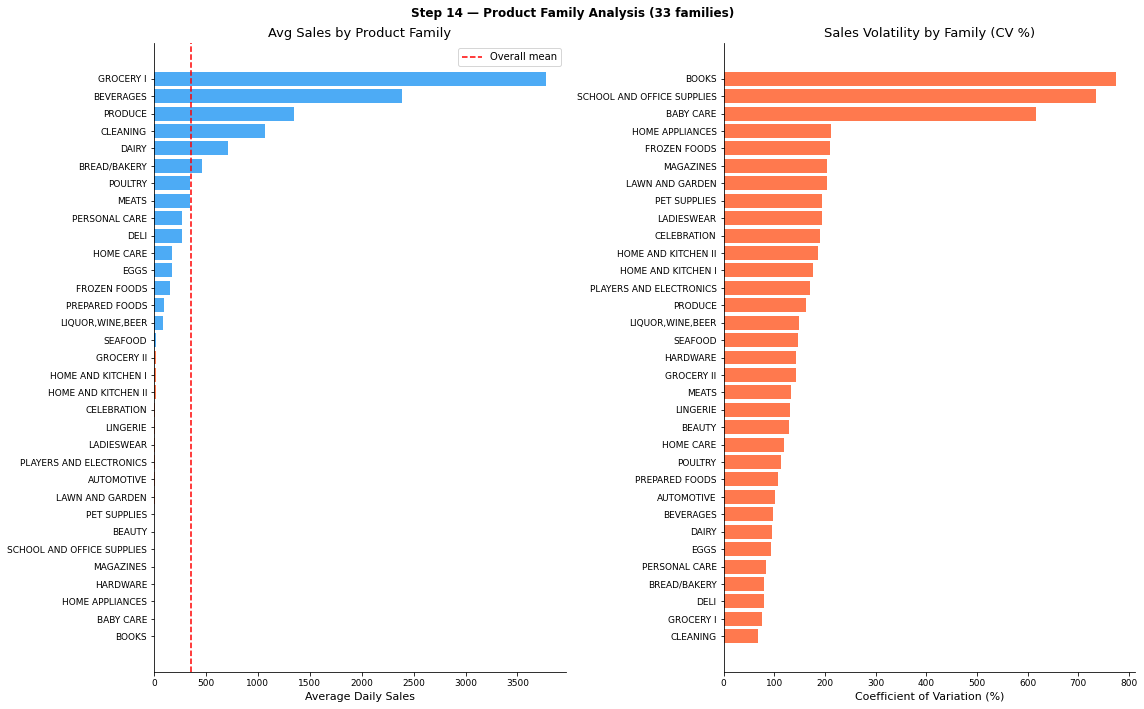


Top 5 Families by Sales Volume:
              mean           sum
family                          
GROCERY I  3776.97  3.434627e+08
BEVERAGES  2385.79  2.169545e+08
PRODUCE    1349.35  1.227047e+08
CLEANING   1072.42  9.752129e+07
DAIRY       709.15  6.448771e+07

Top 5 Most Volatile Families (high CV):
                              mean      cv
family                                    
BOOKS                         0.07  774.02
SCHOOL AND OFFICE SUPPLIES    2.96  734.26
BABY CARE                     0.11  616.19
HOME APPLIANCES               0.46  211.94
FROZEN FOODS                154.77  209.97

📌 Pipeline Decision:
  → family: target encoding (mean sales per family)
  → family × store interaction: group target encoding


In [16]:

family_stats = df_train.groupby('family')['sales'].agg(['mean','median','sum','std'])
family_stats = family_stats.sort_values('mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Avg sales by family
colors = [COLOR_MAIN if v > family_stats['mean'].median() else COLOR_WARN for v in family_stats['mean']]
axes[0].barh(family_stats.index, family_stats['mean'], color=colors, alpha=0.8)
axes[0].set_title('Avg Sales by Product Family')
axes[0].set_xlabel('Average Daily Sales')
axes[0].axvline(family_stats['mean'].mean(), color='red', linestyle='--', linewidth=1.5, label='Overall mean')
axes[0].legend()

# Coefficient of variation (volatility indicator)
family_stats['cv'] = family_stats['std'] / (family_stats['mean'] + 1e-9) * 100
axes[1].barh(family_stats.sort_values('cv').index,
             family_stats.sort_values('cv')['cv'], color=COLOR_WARN, alpha=0.8)
axes[1].set_title('Sales Volatility by Family (CV %)')
axes[1].set_xlabel('Coefficient of Variation (%)')

plt.suptitle('Step 14 — Product Family Analysis (33 families)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 Families by Sales Volume:")
print(family_stats.sort_values('mean', ascending=False).head(5)[['mean','sum']].round(2).to_string())
print("\nTop 5 Most Volatile Families (high CV):")
print(family_stats.sort_values('cv', ascending=False).head(5)[['mean','cv']].round(2).to_string())
print(f"\n📌 Pipeline Decision:")
print(f"  → family: target encoding (mean sales per family)")
print(f"  → family × store interaction: group target encoding")


---
## Step 15 — Promotion (onpromotion) Impact Analysis

**Why:** `onpromotion` is the most directly controllable sales driver. More items on promotion → higher sales. This is one of the strongest predictors.  
**Observation:** Days with high onpromotion count consistently show elevated sales.  
**Pipeline Decision:** Include `onpromotion`, `promo_lag_7`, `promo_rolling_mean_14` as features.


PROMOTION ANALYSIS
  onpromotion range: 0 → 741
  onpromotion mean : 2.60
  Zero promotion   : 79.6% of rows


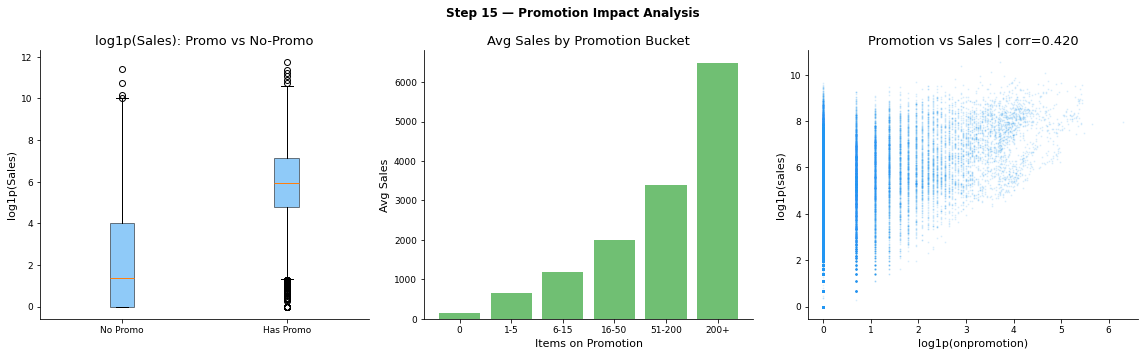


  Mann-Whitney U test (Promo > No-Promo):
    U-statistic: 1274034615982.50 | p-value: 0.00e+00
    Result: Significant ✅
    Promo mean: 1137.69 vs No-promo mean: 158.25

📌 Pipeline Decision:
  → onpromotion is a KEY feature → include + create promo lags
  → Features: onpromotion, promo_lag_7, promo_rolling_14


In [17]:

print("=" * 60)
print("PROMOTION ANALYSIS")
print("=" * 60)

print(f"  onpromotion range: {df_train['onpromotion'].min()} → {df_train['onpromotion'].max()}")
print(f"  onpromotion mean : {df_train['onpromotion'].mean():.2f}")
print(f"  Zero promotion   : {(df_train['onpromotion']==0).mean()*100:.1f}% of rows")

df_promo = df_train.copy()
df_promo['has_promo'] = (df_promo['onpromotion'] > 0).astype(int)
df_promo['promo_bucket'] = pd.cut(df_promo['onpromotion'], bins=[-1,0,5,15,50,200,1000],
                                   labels=['0','1-5','6-15','16-50','51-200','200+'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Promo vs no promo box plot
promo_yes = df_promo[df_promo['has_promo']==1]['sales']
promo_no  = df_promo[df_promo['has_promo']==0]['sales']

axes[0].boxplot([np.log1p(promo_no), np.log1p(promo_yes)],
                labels=['No Promo', 'Has Promo'], patch_artist=True,
                boxprops=dict(facecolor=COLOR_MAIN, alpha=0.5))
axes[0].set_title(f'log1p(Sales): Promo vs No-Promo')
axes[0].set_ylabel('log1p(Sales)')

# Mean sales by promo bucket
bucket_sales = df_promo.groupby('promo_bucket', observed=True)['sales'].mean()
axes[1].bar(bucket_sales.index.astype(str), bucket_sales.values, color=COLOR_OK, alpha=0.8)
axes[1].set_title('Avg Sales by Promotion Bucket')
axes[1].set_xlabel('Items on Promotion')
axes[1].set_ylabel('Avg Sales')

# Correlation: onpromotion vs sales
sample_df = df_promo.sample(min(50000, len(df_promo)), random_state=42)
axes[2].scatter(np.log1p(sample_df['onpromotion']),
                np.log1p(sample_df['sales']),
                alpha=0.1, s=1, color=COLOR_MAIN)
axes[2].set_title(f"Promotion vs Sales | corr={sample_df['onpromotion'].corr(sample_df['sales']):.3f}")
axes[2].set_xlabel('log1p(onpromotion)')
axes[2].set_ylabel('log1p(sales)')

plt.suptitle('Step 15 — Promotion Impact Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical test
stat, p_val = mannwhitneyu(promo_yes, promo_no, alternative='greater')
print(f"\n  Mann-Whitney U test (Promo > No-Promo):")
print(f"    U-statistic: {stat:.2f} | p-value: {p_val:.2e}")
print(f"    Result: {'Significant ✅' if p_val < 0.05 else 'Not significant'}")
print(f"    Promo mean: {promo_yes.mean():.2f} vs No-promo mean: {promo_no.mean():.2f}")
print(f"\n📌 Pipeline Decision:")
print(f"  → onpromotion is a KEY feature → include + create promo lags")
print(f"  → Features: onpromotion, promo_lag_7, promo_rolling_14")


---
## Step 16 — Oil Price Analysis & Sales Correlation

**Why:** Ecuador is oil-dependent. Oil price crashes → economic downturn → consumer spending drops → lower grocery sales. Oil price is an exogenous variable available for both train and test periods.  
**Missing values:** Oil price not reported on weekends/holidays → forward-fill strategy.  
**Imputation:** Oil has outliers? Check → use median or forward-fill for time series continuity.


OIL PRICE ANALYSIS
  Oil price range  : 26.19 → 110.62
  Skewness         : 0.3212
  IQR Outliers     : 0
  Missing values   : 43
  Imputation rule  : Skew=0.32, Outliers=0 → use FORWARD-FILL (time series)


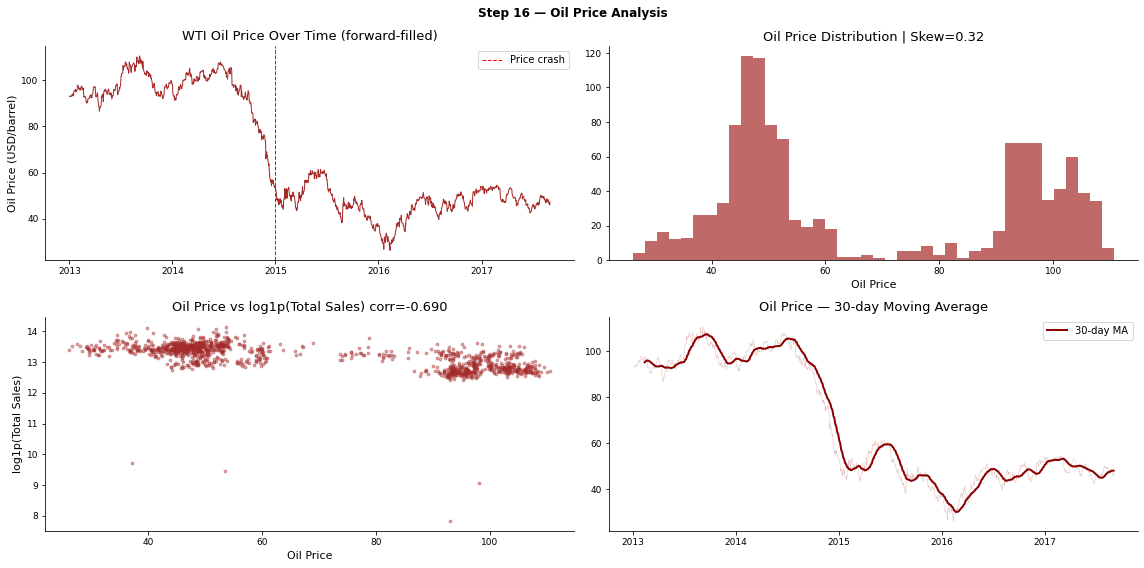


📌 Imputation Decision:
  → Oil price is TIME SERIES → forward-fill (not mean/median)
  → Remaining NaN after ffill → backward-fill
  → Feature: dcoilwtico (oil price) + oil_ma_7, oil_ma_30


In [18]:

print("=" * 60)
print("OIL PRICE ANALYSIS")
print("=" * 60)

oil = df_oil.copy().sort_values('date')
oil_skew = skew(oil['dcoilwtico'].dropna())
oil_q1   = oil['dcoilwtico'].quantile(0.25)
oil_q3   = oil['dcoilwtico'].quantile(0.75)
oil_iqr  = oil_q3 - oil_q1
oil_outliers = ((oil['dcoilwtico'] < oil_q1 - 1.5*oil_iqr) |
                (oil['dcoilwtico'] > oil_q3 + 1.5*oil_iqr)).sum()

print(f"  Oil price range  : {oil['dcoilwtico'].min():.2f} → {oil['dcoilwtico'].max():.2f}")
print(f"  Skewness         : {oil_skew:.4f}")
print(f"  IQR Outliers     : {oil_outliers}")
print(f"  Missing values   : {oil['dcoilwtico'].isna().sum()}")
print(f"  Imputation rule  : Skew={oil_skew:.2f}, Outliers={oil_outliers} → use FORWARD-FILL (time series)")

# Impute oil
oil['dcoilwtico_ffill'] = oil['dcoilwtico'].ffill().bfill()

# Merge with daily sales
daily_sales = df_train.groupby('date')['sales'].sum().reset_index()
daily_oil   = daily_sales.merge(oil[['date','dcoilwtico_ffill']], on='date', how='left')

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Oil price over time
axes[0,0].plot(oil['date'], oil['dcoilwtico_ffill'], color='brown', linewidth=1)
axes[0,0].set_title('WTI Oil Price Over Time (forward-filled)')
axes[0,0].set_ylabel('Oil Price (USD/barrel)')
axes[0,0].axvline(pd.Timestamp('2015-01-01'), color='red', linestyle='--', linewidth=1, label='Price crash')
axes[0,0].legend()

# Oil distribution
axes[0,1].hist(oil['dcoilwtico'].dropna(), bins=40, color='brown', alpha=0.7, edgecolor='none')
axes[0,1].set_title('Oil Price Distribution | Skew=' + f'{oil_skew:.2f}')
axes[0,1].set_xlabel('Oil Price')

# Correlation scatter
valid_mask = daily_oil['dcoilwtico_ffill'].notna()
axes[1,0].scatter(daily_oil.loc[valid_mask, 'dcoilwtico_ffill'],
                  np.log1p(daily_oil.loc[valid_mask, 'sales']),
                  alpha=0.4, s=8, color='brown')
corr_val = daily_oil['dcoilwtico_ffill'].corr(daily_oil['sales'])
axes[1,0].set_title(f'Oil Price vs log1p(Total Sales) corr={corr_val:.3f}')
axes[1,0].set_xlabel('Oil Price')
axes[1,0].set_ylabel('log1p(Total Sales)')

# Oil rolling avg
oil['ma_30'] = oil['dcoilwtico_ffill'].rolling(30).mean()
axes[1,1].plot(oil['date'], oil['dcoilwtico_ffill'], alpha=0.3, color='brown', linewidth=0.5)
axes[1,1].plot(oil['date'], oil['ma_30'], color='darkred', linewidth=2, label='30-day MA')
axes[1,1].set_title('Oil Price — 30-day Moving Average')
axes[1,1].legend()

plt.suptitle('Step 16 — Oil Price Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Imputation Decision:")
print(f"  → Oil price is TIME SERIES → forward-fill (not mean/median)")
print(f"  → Remaining NaN after ffill → backward-fill")
print(f"  → Feature: dcoilwtico (oil price) + oil_ma_7, oil_ma_30")


---
## Step 17 — Holiday & Events Analysis

**Why:** Holidays cause massive sales spikes or dips (stores closed). Ecuador has National, Regional, and Local holidays — each affects only certain stores. Transferred holidays must be handled carefully.  
**Pipeline Decision:** Create binary flags: `is_holiday`, `is_national_holiday`, `days_to_next_holiday`, `days_since_last_holiday`.


HOLIDAYS & EVENTS ANALYSIS
  Total holiday entries: 350
  Date range: 2012-03-02 → 2017-12-26

  Holiday types:
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5

  Locale breakdown:
locale
National    174
Local       152
Regional     24

  Transferred holidays: 12
  (These actually occur on a different date than listed)


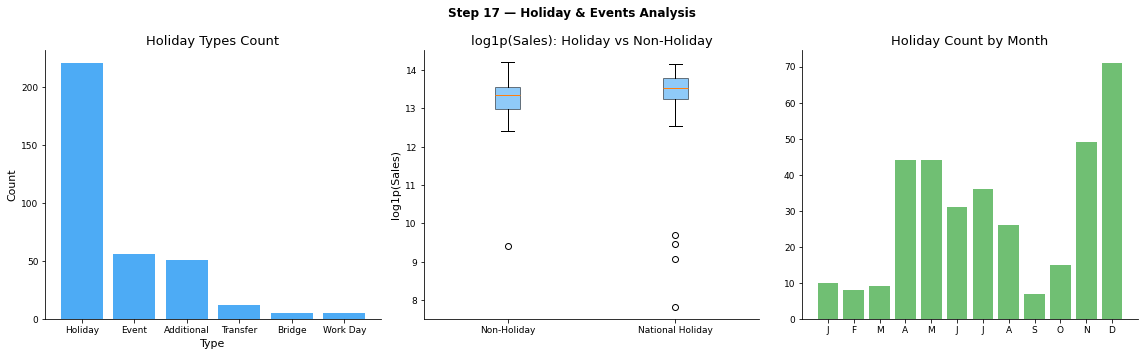

  Mann-Whitney U (Holiday vs Non-Holiday): p=0.0000
  National holiday sales mean: 13.363 vs Non-holiday: 13.280

📌 Pipeline Decision:
  → is_national_holiday, is_regional_holiday, is_local_holiday (binary flags)
  → days_to_next_holiday, days_since_last_holiday (proximity features)
  → Handle transferred=True → actual date is different


In [19]:

print("=" * 60)
print("HOLIDAYS & EVENTS ANALYSIS")
print("=" * 60)

print(f"  Total holiday entries: {len(df_holidays)}")
print(f"  Date range: {df_holidays['date'].min().date()} → {df_holidays['date'].max().date()}")
print(f"\n  Holiday types:")
print(df_holidays['type'].value_counts().to_string())
print(f"\n  Locale breakdown:")
print(df_holidays['locale'].value_counts().to_string())

# Transferred holidays
transferred = df_holidays[df_holidays['transferred'] == True]
print(f"\n  Transferred holidays: {len(transferred)}")
print(f"  (These actually occur on a different date than listed)")

# National holidays only — affect all stores
national_hols = df_holidays[
    (df_holidays['locale'] == 'National') & (df_holidays['transferred'] == False)
]['date'].unique()

# Merge national holidays with daily sales
daily_s = df_train.groupby('date')['sales'].sum().reset_index()
daily_s['is_national_holiday'] = daily_s['date'].isin(national_hols).astype(int)
daily_s['log_sales'] = np.log1p(daily_s['sales'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Holiday type counts
type_counts = df_holidays['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=COLOR_MAIN, alpha=0.8)
axes[0].set_title('Holiday Types Count')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')

# Sales on holiday vs non-holiday
hol_sales    = daily_s[daily_s['is_national_holiday']==1]['log_sales']
nonhol_sales = daily_s[daily_s['is_national_holiday']==0]['log_sales']
axes[1].boxplot([nonhol_sales, hol_sales], labels=['Non-Holiday','National Holiday'],
                patch_artist=True, boxprops=dict(facecolor=COLOR_MAIN, alpha=0.5))
axes[1].set_title('log1p(Sales): Holiday vs Non-Holiday')
axes[1].set_ylabel('log1p(Sales)')

# Holidays per month
df_holidays['month'] = df_holidays['date'].dt.month
hol_per_month = df_holidays.groupby('month').size()
axes[2].bar(range(1,13), [hol_per_month.get(m,0) for m in range(1,13)],
            color=COLOR_OK, alpha=0.8)
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[2].set_title('Holiday Count by Month')

plt.suptitle('Step 17 — Holiday & Events Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

stat, p = mannwhitneyu(hol_sales, nonhol_sales, alternative='two-sided')
print(f"  Mann-Whitney U (Holiday vs Non-Holiday): p={p:.4f}")
print(f"  National holiday sales mean: {hol_sales.mean():.3f} vs Non-holiday: {nonhol_sales.mean():.3f}")
print(f"\n📌 Pipeline Decision:")
print(f"  → is_national_holiday, is_regional_holiday, is_local_holiday (binary flags)")
print(f"  → days_to_next_holiday, days_since_last_holiday (proximity features)")
print(f"  → Handle transferred=True → actual date is different")


---
## Step 18 — Transactions Analysis

**Why:** Transaction count = store footfall proxy. High transactions → more items purchased. Transactions data is only available for training period (not test) → use lagged transactions as feature.  
**Missing:** transactions.csv is missing data for some store-date combos.


TRANSACTIONS ANALYSIS
  Shape: (83488, 3)
  Date range: 2013-01-01 → 2017-08-15
  Unique stores: 54

  Transactions stats:
    Skewness : 1.5183
    Outliers : 4583 (5.5%)
    Missing  : 0
  Imputation: Skew=1.52, Outliers=4583 → use MEDIAN

  Missing transactions after merge: 7,448 (8.2%)


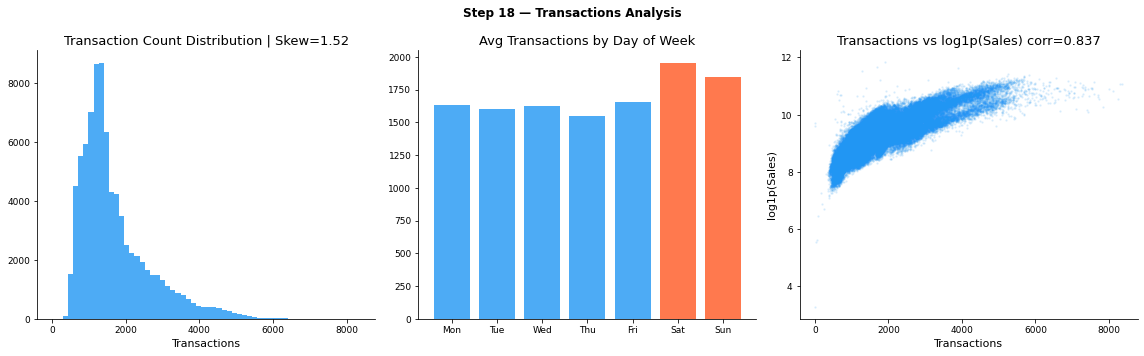


📌 Pipeline Decision:
  → transactions: corr=0.837 with sales → STRONG predictor
  → Impute missing with MEDIAN (has outliers: 4583 rows)
  → Features: transactions, txn_lag_7, txn_rolling_7
  → WARNING: transactions not in test → use LAGGED values only


In [20]:

print("=" * 60)
print("TRANSACTIONS ANALYSIS")
print("=" * 60)

print(f"  Shape: {df_transactions.shape}")
print(f"  Date range: {df_transactions['date'].min().date()} → {df_transactions['date'].max().date()}")
print(f"  Unique stores: {df_transactions['store_nbr'].nunique()}")

txn_skew = skew(df_transactions['transactions'].dropna())
txn_q1   = df_transactions['transactions'].quantile(0.25)
txn_q3   = df_transactions['transactions'].quantile(0.75)
txn_iqr  = txn_q3 - txn_q1
txn_outliers = ((df_transactions['transactions'] < txn_q1 - 1.5*txn_iqr) |
                (df_transactions['transactions'] > txn_q3 + 1.5*txn_iqr)).sum()

print(f"\n  Transactions stats:")
print(f"    Skewness : {txn_skew:.4f}")
print(f"    Outliers : {txn_outliers} ({txn_outliers/len(df_transactions)*100:.1f}%)")
print(f"    Missing  : {df_transactions['transactions'].isna().sum()}")
print(f"  Imputation: Skew={txn_skew:.2f}, Outliers={txn_outliers} → use MEDIAN")

# Merge to check coverage
train_dates = df_train[['date','store_nbr']].drop_duplicates()
txn_merged  = train_dates.merge(df_transactions, on=['date','store_nbr'], how='left')
miss_txn    = txn_merged['transactions'].isna().sum()
print(f"\n  Missing transactions after merge: {miss_txn:,} ({miss_txn/len(txn_merged)*100:.1f}%)")

# Correlation with sales
daily_merged = df_train.groupby(['date','store_nbr'])['sales'].sum().reset_index()
daily_merged = daily_merged.merge(df_transactions, on=['date','store_nbr'], how='left')

corr = daily_merged['transactions'].corr(daily_merged['sales'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Transactions distribution
axes[0].hist(df_transactions['transactions'].dropna(), bins=60,
             color=COLOR_MAIN, alpha=0.8, edgecolor='none')
axes[0].set_title('Transaction Count Distribution | Skew=' + f'{txn_skew:.2f}')
axes[0].set_xlabel('Transactions')

# Transactions by day of week
df_transactions['dow'] = df_transactions['date'].dt.dayofweek
txn_dow = df_transactions.groupby('dow')['transactions'].mean()
axes[1].bar(range(7), txn_dow.values,
            color=[COLOR_WARN if i >= 5 else COLOR_MAIN for i in range(7)], alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_title('Avg Transactions by Day of Week')

# Correlation scatter
valid = daily_merged.dropna(subset=['transactions'])
axes[2].scatter(valid['transactions'], np.log1p(valid['sales']),
                alpha=0.1, s=2, color=COLOR_MAIN)
axes[2].set_title(f'Transactions vs log1p(Sales) corr={corr:.3f}')
axes[2].set_xlabel('Transactions')
axes[2].set_ylabel('log1p(Sales)')

plt.suptitle('Step 18 — Transactions Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Pipeline Decision:")
print(f"  → transactions: corr={corr:.3f} with sales → STRONG predictor")
print(f"  → Impute missing with MEDIAN (has outliers: {txn_outliers} rows)")
print(f"  → Features: transactions, txn_lag_7, txn_rolling_7")
print(f"  → WARNING: transactions not in test → use LAGGED values only")


---
## Step 19 — Store Metadata Analysis (type, cluster, city, state)

**Why:** Store type and cluster group similar stores together. Cluster is a geographic-commercial grouping by Favorita. City and state affect local economic conditions.  
**Pipeline Decision:** type → OrdinalEncoder. cluster → numeric (already). city/state → target encoding.


STORE METADATA
 store_nbr          city                          state type  cluster
         1         Quito                      Pichincha    D       13
         2         Quito                      Pichincha    D       13
         3         Quito                      Pichincha    D        8
         4         Quito                      Pichincha    D        9
         5 Santo Domingo Santo Domingo de los Tsachilas    D        4
         6         Quito                      Pichincha    D       13
         7         Quito                      Pichincha    D        8
         8         Quito                      Pichincha    D        8
         9         Quito                      Pichincha    B        6
        10         Quito                      Pichincha    C       15
        11       Cayambe                      Pichincha    B        6
        12     Latacunga                       Cotopaxi    C       15
        13     Latacunga                       Cotopaxi    C       15
     

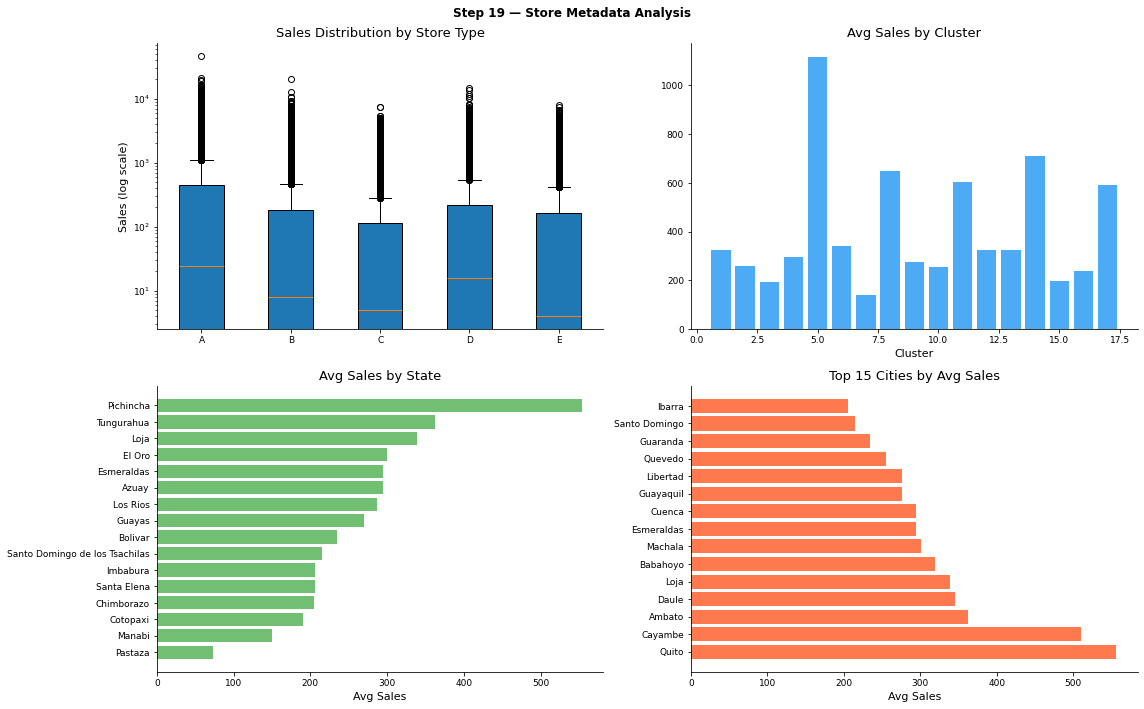


📌 Pipeline Decision:
  → type (A/B/C/D/E)  : OrdinalEncoder or Label encoding
  → cluster (1-17)    : numeric (already int) → keep as-is
  → city, state       : target encoding (mean sales per city/state)


In [21]:

print("=" * 60)
print("STORE METADATA")
print("=" * 60)
print(df_stores.to_string(index=False))

print(f"\n  Store Type distribution:")
print(df_stores['type'].value_counts().to_string())
print(f"\n  Cluster distribution (1-17):")
print(df_stores['cluster'].value_counts().sort_index().to_string())
print(f"\n  Cities: {df_stores['city'].nunique()} unique cities")
print(f"  States: {df_stores['state'].nunique()} unique states")

# Merge with train sales
train_with_meta = df_train.merge(df_stores, on='store_nbr')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# By store type — boxplot
type_data = [train_with_meta[train_with_meta['type']==t]['sales'].sample(min(5000,sum(train_with_meta['type']==t)), random_state=42)
             for t in sorted(df_stores['type'].unique())]
axes[0,0].boxplot(type_data, labels=sorted(df_stores['type'].unique()), patch_artist=True)
axes[0,0].set_title('Sales Distribution by Store Type')
axes[0,0].set_yscale('log')
axes[0,0].set_ylabel('Sales (log scale)')

# By cluster — mean sales
cluster_mean = train_with_meta.groupby('cluster')['sales'].mean().sort_index()
axes[0,1].bar(cluster_mean.index, cluster_mean.values, color=COLOR_MAIN, alpha=0.8)
axes[0,1].set_title('Avg Sales by Cluster')
axes[0,1].set_xlabel('Cluster')

# By state
state_mean = train_with_meta.groupby('state')['sales'].mean().sort_values(ascending=True)
axes[1,0].barh(state_mean.index, state_mean.values, color=COLOR_OK, alpha=0.8)
axes[1,0].set_title('Avg Sales by State')
axes[1,0].set_xlabel('Avg Sales')

# By city (top 15)
city_mean = train_with_meta.groupby('city')['sales'].mean().sort_values(ascending=False).head(15)
axes[1,1].barh(city_mean.index, city_mean.values, color=COLOR_WARN, alpha=0.8)
axes[1,1].set_title('Top 15 Cities by Avg Sales')
axes[1,1].set_xlabel('Avg Sales')

plt.suptitle('Step 19 — Store Metadata Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Pipeline Decision:")
print(f"  → type (A/B/C/D/E)  : OrdinalEncoder or Label encoding")
print(f"  → cluster (1-17)    : numeric (already int) → keep as-is")
print(f"  → city, state       : target encoding (mean sales per city/state)")


---
## Step 20 — Feature Correlation Analysis

**Why:** Identify highly correlated features (multicollinearity). For LightGBM this matters less, but for feature selection and understanding feature redundancy it's important.  
**Note:** Correlation here is on the engineered merged dataset.


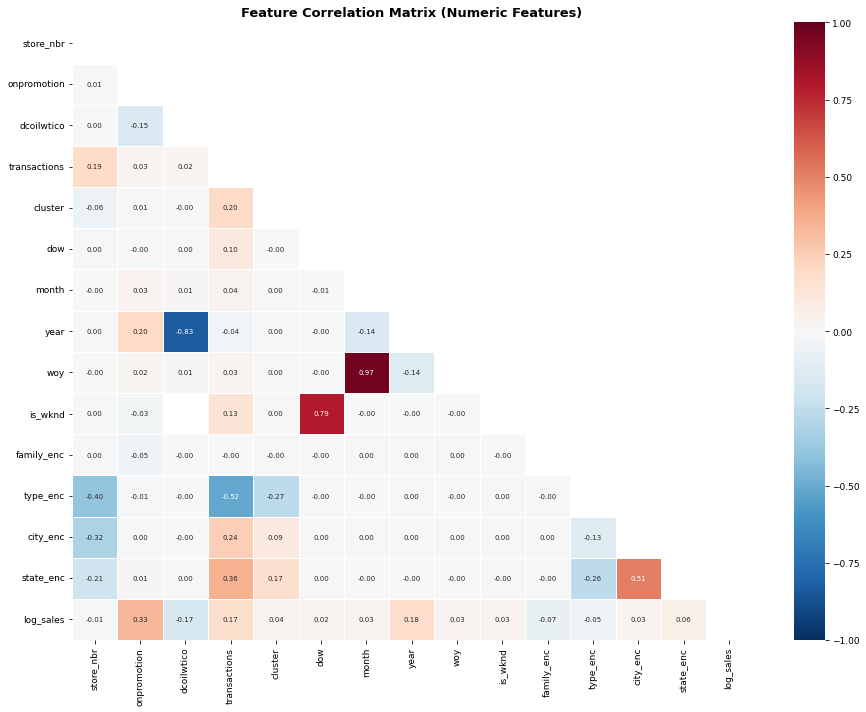


Correlation with log1p(sales):
onpromotion     0.3292
year            0.1833
transactions    0.1729
dcoilwtico     -0.1700
family_enc     -0.0749
state_enc       0.0624
type_enc       -0.0464
cluster         0.0374
month           0.0346
is_wknd         0.0328
city_enc        0.0307
woy             0.0284
dow             0.0236
store_nbr      -0.0099

📌 Pipeline Decision:
  → No severe multicollinearity expected for tree-based models
  → High corr pairs: keep both for LightGBM (handles internally)


In [22]:

# Build merged dataframe with numeric features
merged = df_train.copy()
merged = merged.merge(df_stores, on='store_nbr', how='left')
merged = merged.merge(df_oil[['date','dcoilwtico']].ffill(), on='date', how='left')
merged = merged.merge(df_transactions, on=['date','store_nbr'], how='left')

merged['dow']     = merged['date'].dt.dayofweek
merged['month']   = merged['date'].dt.month
merged['year']    = merged['date'].dt.year
merged['woy']     = merged['date'].dt.isocalendar().week.astype(int)
merged['is_wknd'] = (merged['dow'] >= 5).astype(int)
merged['log_sales'] = np.log1p(merged['sales'])

# Encode categoricals
from sklearn.preprocessing import LabelEncoder
for col in ['family', 'type', 'city', 'state']:
    if col in merged.columns:
        merged[col+'_enc'] = LabelEncoder().fit_transform(merged[col].astype(str))

numeric_feats = ['store_nbr','onpromotion','dcoilwtico','transactions','cluster',
                 'dow','month','year','woy','is_wknd',
                 'family_enc','type_enc','city_enc','state_enc','log_sales']
numeric_feats = [c for c in numeric_feats if c in merged.columns]

corr_matrix = merged[numeric_feats].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Target correlations
target_corr = corr_matrix['log_sales'].drop('log_sales').sort_values(key=abs, ascending=False)
print("\nCorrelation with log1p(sales):")
print(target_corr.round(4).to_string())
print(f"\n📌 Pipeline Decision:")
print(f"  → No severe multicollinearity expected for tree-based models")
print(f"  → High corr pairs: keep both for LightGBM (handles internally)")


---
## Step 21 — Missing Value Imputation Strategy (Final Decision)

**Why:** Consolidate all imputation decisions made in Steps 3, 16, 18 into a single reference. This becomes the specification for `data_loader.py`.  
**Final Rules:**
- `oil.dcoilwtico`: time series → forward-fill then backward-fill
- `transactions`: has outliers (IQR check) → **median** imputation per store
- All other features in train.csv → no missing values


FINAL IMPUTATION STRATEGY — PIPELINE SPECIFICATION
  Feature                                    Strategy                       Reason
  ----------------------------------------------------------------------------------------------------
  dcoilwtico (oil price)                     ffill() then bfill()           Time series — carry last known price
  transactions                               Median per store_nbr           Outliers present → median safer than mean
  store metadata (city,state,type,cluster)   N/A                            stores.csv is complete
  sales (target)                             N/A                            train.csv has no missing values
  onpromotion                                N/A                            train.csv has no missing values
  holiday flags                              Fill 0 (no holiday)            Date not in holidays_events → 0


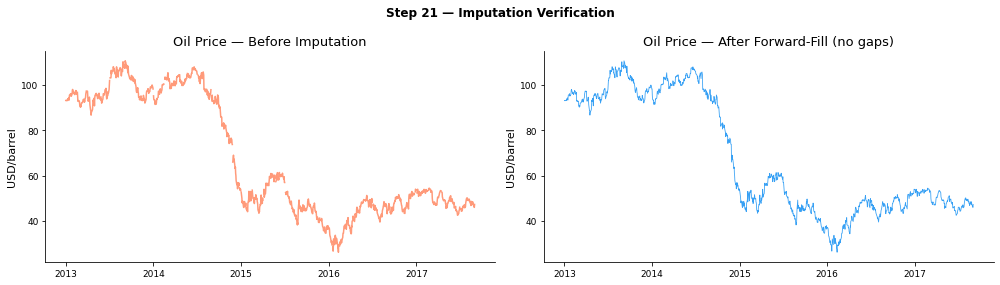


✅ Imputation decisions finalized — ready for pipeline implementation


In [23]:

print("=" * 60)
print("FINAL IMPUTATION STRATEGY — PIPELINE SPECIFICATION")
print("=" * 60)

imputation_plan = [
    ('dcoilwtico (oil price)', 'Continuous', 'Time series',
     'ffill() then bfill()', 'Time series — carry last known price'),
    ('transactions', 'Continuous', 'Has outliers (IQR check)',
     'Median per store_nbr', 'Outliers present → median safer than mean'),
    ('store metadata (city,state,type,cluster)', 'Categorical', 'No missing',
     'N/A', 'stores.csv is complete'),
    ('sales (target)', 'Continuous', 'No missing',
     'N/A', 'train.csv has no missing values'),
    ('onpromotion', 'Integer', 'No missing',
     'N/A', 'train.csv has no missing values'),
    ('holiday flags', 'Derived binary', 'N/A — created from merge',
     'Fill 0 (no holiday)', 'Date not in holidays_events → 0'),
]

print(f"  {'Feature':<42} {'Strategy':<30} {'Reason'}")
print(f"  {'-'*100}")
for feat, dtype, dist, strategy, reason in imputation_plan:
    print(f"  {feat:<42} {strategy:<30} {reason}")

# Verify oil imputation visually
oil_imp = df_oil.copy().sort_values('date')
oil_imp['dcoilwtico_ffill'] = oil_imp['dcoilwtico'].ffill().bfill()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(oil_imp['date'], oil_imp['dcoilwtico'], label='Original (with gaps)', alpha=0.6, color=COLOR_WARN)
axes[0].set_title('Oil Price — Before Imputation')
axes[0].set_ylabel('USD/barrel')

axes[1].plot(oil_imp['date'], oil_imp['dcoilwtico_ffill'], label='After ffill+bfill',
             alpha=0.9, color=COLOR_MAIN, linewidth=0.8)
axes[1].set_title('Oil Price — After Forward-Fill (no gaps)')
axes[1].set_ylabel('USD/barrel')

plt.suptitle('Step 21 — Imputation Verification', fontweight='bold')
plt.tight_layout()
plt.show()
print("\n✅ Imputation decisions finalized — ready for pipeline implementation")


---
## Step 22 — Lag Feature Preview (7d, 14d, 28d)

**Why:** Lag features are the BACKBONE of time series ML. Yesterday's sales predict today's sales. For LightGBM (non-recursive forecasting), we create lag features from training data for the 16-day forecast window.  
**Key Insight:** We need lags ≥ 16 for the test period (test = 16 days, last lag available = day 16 back).


LAG FEATURE ENGINEERING PREVIEW
  Sample: Store #1 | Family: GROCERY I
  Lag 7  correlation with target: 0.5808
  Lag 14 correlation with target: 0.5845
  Lag 28 correlation with target: 0.5479


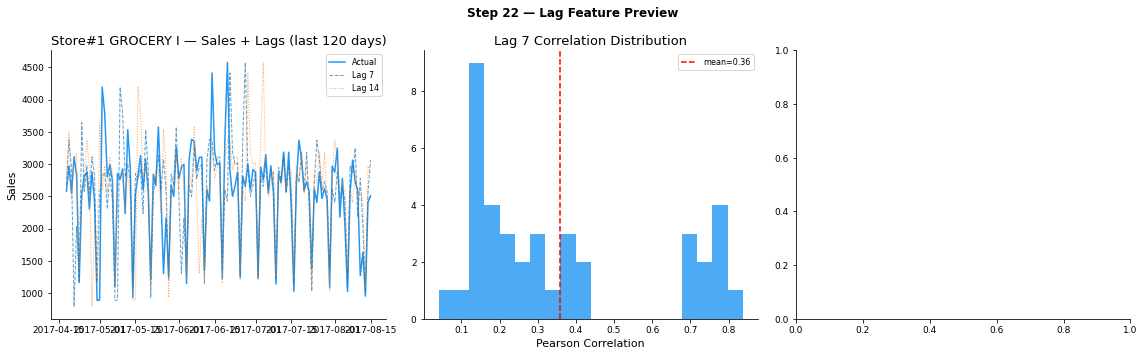


📌 Pipeline Decision:
  → Minimum lag = 16 (test horizon)
  → Lags to create: 16, 21, 28, 35, 42 days
  → Also create: lag_same_weekday_1yr (lag_365)


In [24]:

print("=" * 60)
print("LAG FEATURE ENGINEERING PREVIEW")
print("=" * 60)

# Aggregate to store-family level (one of the 54×33 = 1782 time series)
sample_store   = 1
sample_family  = 'GROCERY I'
sample_ts = df_train[
    (df_train['store_nbr'] == sample_store) &
    (df_train['family'] == sample_family)
].sort_values('date').copy()

# Create lag features
for lag in [7, 14, 28]:
    sample_ts[f'sales_lag_{lag}'] = sample_ts['sales'].shift(lag)

sample_ts['sales_lag_7_corr']  = sample_ts['sales'].corr(sample_ts['sales_lag_7'])
sample_ts['sales_lag_14_corr'] = sample_ts['sales'].corr(sample_ts['sales_lag_14'])
sample_ts['sales_lag_28_corr'] = sample_ts['sales'].corr(sample_ts['sales_lag_28'])

print(f"  Sample: Store #{sample_store} | Family: {sample_family}")
print(f"  Lag 7  correlation with target: {sample_ts['sales'].corr(sample_ts['sales_lag_7']):.4f}")
print(f"  Lag 14 correlation with target: {sample_ts['sales'].corr(sample_ts['sales_lag_14']):.4f}")
print(f"  Lag 28 correlation with target: {sample_ts['sales'].corr(sample_ts['sales_lag_28']):.4f}")

# Lag correlation across all store-family pairs
all_lag_corrs = []
for store in df_train['store_nbr'].unique()[:10]:  # sample 10 stores for speed
    for fam in df_train['family'].unique()[:5]:
        ts = df_train[(df_train['store_nbr']==store) & (df_train['family']==fam)].sort_values('date')
        if len(ts) > 50:
            for lag in [7, 14, 28]:
                c = ts['sales'].corr(ts['sales'].shift(lag))
                all_lag_corrs.append({'store':store,'family':fam,'lag':lag,'corr':c})

lag_corr_df = pd.DataFrame(all_lag_corrs)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sample TS with lags
axes[0].plot(sample_ts['date'].iloc[-120:], sample_ts['sales'].iloc[-120:],
             label='Actual', linewidth=1.5, color=COLOR_MAIN)
axes[0].plot(sample_ts['date'].iloc[-120:], sample_ts['sales_lag_7'].iloc[-120:],
             label='Lag 7', linewidth=1, alpha=0.7, linestyle='--')
axes[0].plot(sample_ts['date'].iloc[-120:], sample_ts['sales_lag_14'].iloc[-120:],
             label='Lag 14', linewidth=1, alpha=0.7, linestyle=':')
axes[0].set_title(f'Store#{sample_store} {sample_family} — Sales + Lags (last 120 days)')
axes[0].legend(fontsize=8)
axes[0].set_ylabel('Sales')

# Lag correlation distribution
for lag, ax in zip([7, 14, 28], axes[1:3]):
    lag_data = lag_corr_df[lag_corr_df['lag']==lag]['corr'].dropna()
    if len(lag_data):
        ax.hist(lag_data, bins=20, color=COLOR_MAIN, alpha=0.8)
        ax.axvline(lag_data.mean(), color='red', linestyle='--', label=f'mean={lag_data.mean():.2f}')
        ax.set_title(f'Lag {lag} Correlation Distribution')
        ax.set_xlabel('Pearson Correlation')
        ax.legend(fontsize=8)
        break

plt.suptitle('Step 22 — Lag Feature Preview', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Pipeline Decision:")
print(f"  → Minimum lag = 16 (test horizon)")
print(f"  → Lags to create: 16, 21, 28, 35, 42 days")
print(f"  → Also create: lag_same_weekday_1yr (lag_365)")


---
## Step 23 — Rolling Statistics Preview

**Why:** Rolling mean/std capture recent trend and volatility. They smooth out noise and help the model understand whether a store-family is in an upswing or downswing.  
**Features:** rolling_mean_7, rolling_mean_14, rolling_mean_28, rolling_std_14, rolling_median_7.


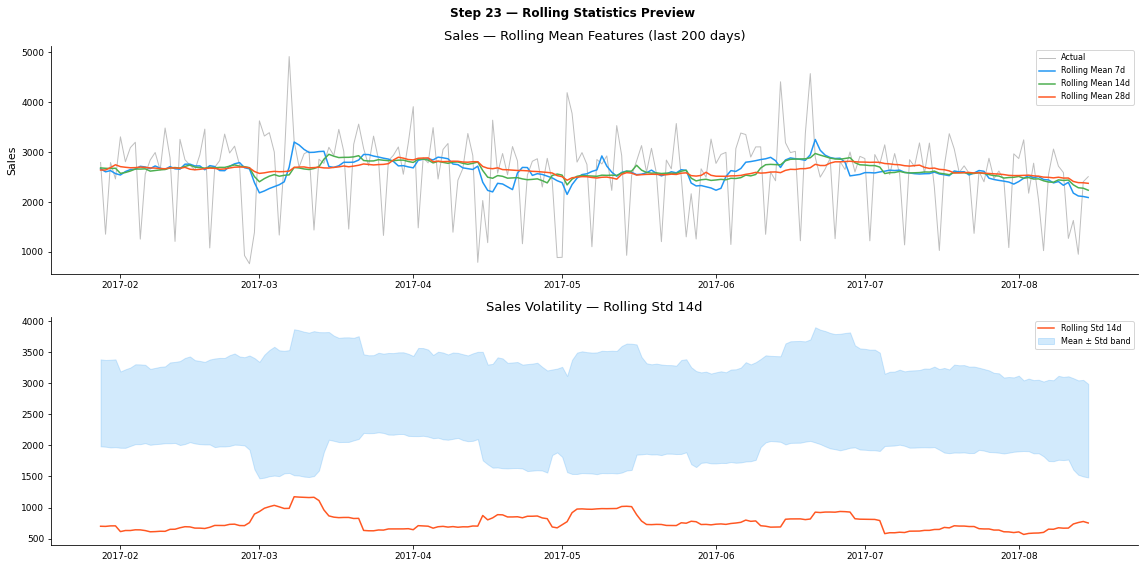

📌 Pipeline Decision:
  → rolling_mean_7, 14, 28 (shifted by 1 to avoid leakage)
  → rolling_std_14 (volatility feature)
  → rolling_median_7 (robust to spikes)
  → IMPORTANT: always shift(1) before rolling to prevent data leakage!


In [25]:

sample_ts2 = df_train[
    (df_train['store_nbr'] == 1) & (df_train['family'] == 'GROCERY I')
].sort_values('date').copy()

for window in [7, 14, 28]:
    sample_ts2[f'rolling_mean_{window}'] = sample_ts2['sales'].shift(1).rolling(window).mean()
    sample_ts2[f'rolling_std_{window}']  = sample_ts2['sales'].shift(1).rolling(window).std()

plot_ts = sample_ts2.iloc[-200:].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(plot_ts['date'], plot_ts['sales'], label='Actual', alpha=0.5, color='grey', linewidth=1)
for window, color in zip([7, 14, 28], [COLOR_MAIN, COLOR_OK, COLOR_WARN]):
    axes[0].plot(plot_ts['date'], plot_ts[f'rolling_mean_{window}'],
                 label=f'Rolling Mean {window}d', linewidth=1.5, color=color)
axes[0].set_title('Sales — Rolling Mean Features (last 200 days)')
axes[0].legend(fontsize=8)
axes[0].set_ylabel('Sales')

# Rolling std (volatility)
axes[1].plot(plot_ts['date'], plot_ts['rolling_std_14'],
             label='Rolling Std 14d', color=COLOR_WARN, linewidth=1.5)
axes[1].fill_between(plot_ts['date'],
                     plot_ts['rolling_mean_14'] - plot_ts['rolling_std_14'],
                     plot_ts['rolling_mean_14'] + plot_ts['rolling_std_14'],
                     alpha=0.2, color=COLOR_MAIN, label='Mean ± Std band')
axes[1].set_title('Sales Volatility — Rolling Std 14d')
axes[1].legend(fontsize=8)

plt.suptitle('Step 23 — Rolling Statistics Preview', fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Pipeline Decision:")
print("  → rolling_mean_7, 14, 28 (shifted by 1 to avoid leakage)")
print("  → rolling_std_14 (volatility feature)")
print("  → rolling_median_7 (robust to spikes)")
print("  → IMPORTANT: always shift(1) before rolling to prevent data leakage!")


---
## Step 24 — Store × Family Cross Analysis

**Why:** Some families sell extremely well in certain stores but not others (e.g., SEAFOOD in coastal stores). The interaction of store × family creates the 1,782 unique time series.  
**Pipeline Decision:** Group target encoding: mean sales per (store_nbr × family) combination.


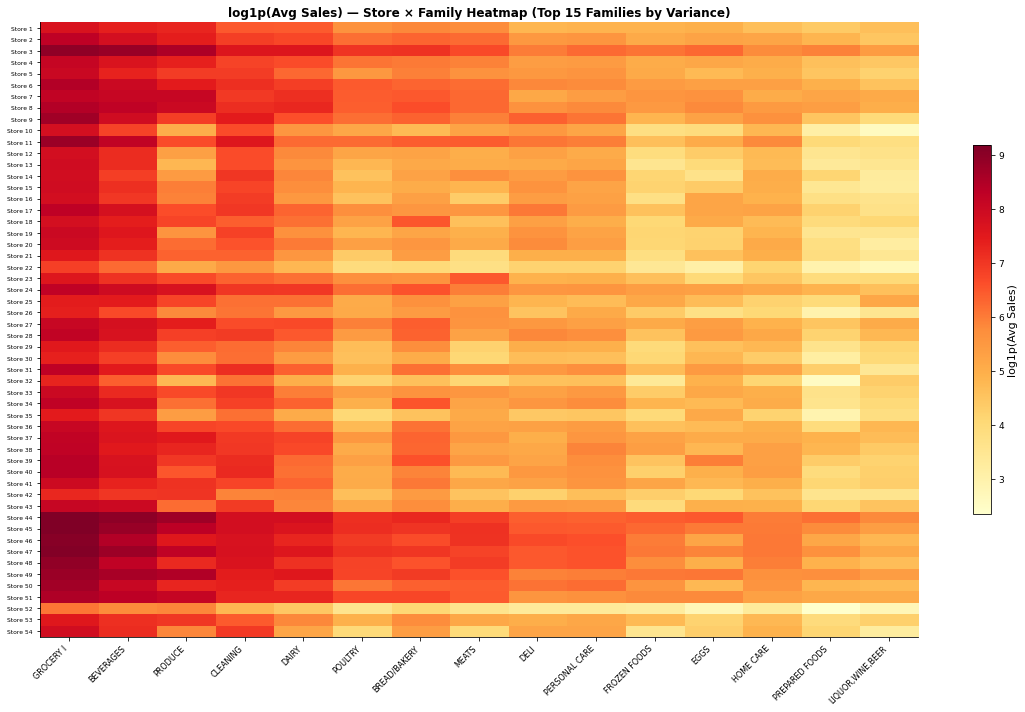

Top 10 Families with Highest Store-to-Store Variation:
family
SCHOOL AND OFFICE SUPPLIES    1.5293
BABY CARE                     1.4831
BOOKS                         1.4242
SEAFOOD                       1.3542
PET SUPPLIES                  1.1507
LAWN AND GARDEN               1.0742
LADIESWEAR                    1.0676
HOME APPLIANCES               1.0333
PRODUCE                       1.0207
MAGAZINES                     1.0113

📌 Pipeline Decision:
  → Create store_family_mean: target encoding of (store × family)
  → This captures 1782 unique series patterns in one feature
  → Prevents one-hot encoding explosion


In [26]:

# Pivot: store × family mean sales heatmap
pivot = df_train.groupby(['store_nbr', 'family'])['sales'].mean().unstack(level='family')

# Top 15 families by variance (most interesting)
fam_variance = pivot.var().sort_values(ascending=False).head(15)
pivot_top = pivot[fam_variance.index]

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(np.log1p(pivot_top.values), aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(fam_variance.index)))
ax.set_xticklabels(fam_variance.index, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'Store {s}' for s in pivot.index], fontsize=6)
ax.set_title('log1p(Avg Sales) — Store × Family Heatmap (Top 15 Families by Variance)',
             fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.6, label='log1p(Avg Sales)')
plt.tight_layout()
plt.show()

# Coefficient of variation across stores for each family
cv_by_family = (pivot.std() / (pivot.mean() + 1e-9)).sort_values(ascending=False)

print("Top 10 Families with Highest Store-to-Store Variation:")
print(cv_by_family.head(10).round(4).to_string())
print(f"\n📌 Pipeline Decision:")
print(f"  → Create store_family_mean: target encoding of (store × family)")
print(f"  → This captures 1782 unique series patterns in one feature")
print(f"  → Prevents one-hot encoding explosion")


---
## Step 25 — Earthquake Event Impact (April 16, 2016)

**Why:** A magnitude 7.8 earthquake hit Ecuador on April 16, 2016. The government waived VAT and ISD taxes → massive shopping spike. This is a real external event that's visible in the data.  
**Pipeline Decision:** Create `is_earthquake_period` binary feature for April 2016.


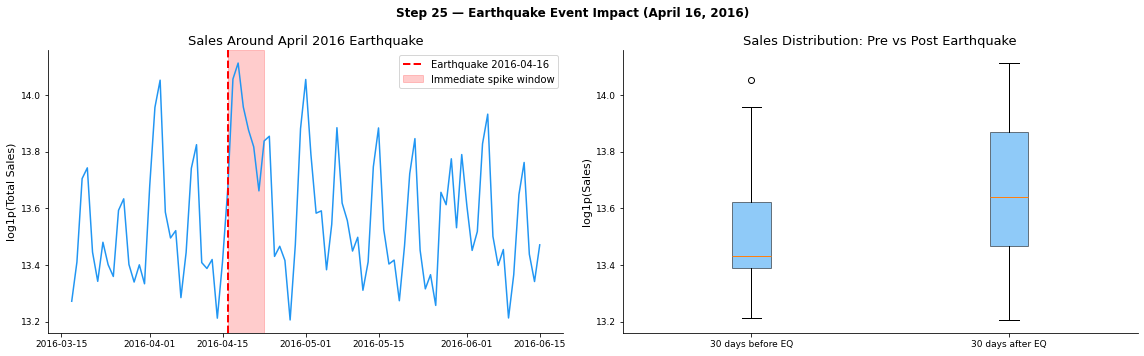

  Pre-earthquake mean  (30d): 13.5092
  Post-earthquake mean (30d): 13.6668
  Difference: +0.1576 (+1.2%)

📌 Pipeline Decision:
  → Feature: is_earthquake_period = 1 for dates 2016-04-16 to 2016-05-16
  → Prophet's changepoint detection will also capture this automatically


In [27]:

eq_date   = pd.Timestamp('2016-04-16')
eq_window = 30  # 30 days around earthquake

daily_sales_eq = df_train.groupby('date')['sales'].sum().reset_index()
daily_sales_eq['log_sales'] = np.log1p(daily_sales_eq['sales'])
daily_sales_eq['is_eq_period'] = (
    (daily_sales_eq['date'] >= eq_date - pd.Timedelta(days=7)) &
    (daily_sales_eq['date'] <= eq_date + pd.Timedelta(days=eq_window))
)

# Zoom in on earthquake period
eq_period_start = eq_date - pd.Timedelta(days=30)
eq_period_end   = eq_date + pd.Timedelta(days=60)
eq_data = daily_sales_eq[
    (daily_sales_eq['date'] >= eq_period_start) &
    (daily_sales_eq['date'] <= eq_period_end)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(eq_data['date'], eq_data['log_sales'], color=COLOR_MAIN, linewidth=1.5)
axes[0].axvline(eq_date, color='red', linestyle='--', linewidth=2, label=f'Earthquake {eq_date.date()}')
axes[0].axvspan(eq_date, eq_date + pd.Timedelta(days=7),
                alpha=0.2, color='red', label='Immediate spike window')
axes[0].set_title('Sales Around April 2016 Earthquake')
axes[0].set_ylabel('log1p(Total Sales)')
axes[0].legend()

# Before vs after
pre_eq  = daily_sales_eq[daily_sales_eq['date'] <  eq_date]['log_sales'].tail(30)
post_eq = daily_sales_eq[daily_sales_eq['date'] >= eq_date]['log_sales'].head(30)
axes[1].boxplot([pre_eq, post_eq], labels=['30 days before EQ', '30 days after EQ'],
                patch_artist=True, boxprops=dict(facecolor=COLOR_MAIN, alpha=0.5))
axes[1].set_title('Sales Distribution: Pre vs Post Earthquake')
axes[1].set_ylabel('log1p(Sales)')

plt.suptitle('Step 25 — Earthquake Event Impact (April 16, 2016)', fontweight='bold')
plt.tight_layout()
plt.show()

pre_mean  = pre_eq.mean()
post_mean = post_eq.mean()
print(f"  Pre-earthquake mean  (30d): {pre_mean:.4f}")
print(f"  Post-earthquake mean (30d): {post_mean:.4f}")
print(f"  Difference: {post_mean - pre_mean:+.4f} ({(post_mean-pre_mean)/pre_mean*100:+.1f}%)")
print(f"\n📌 Pipeline Decision:")
print(f"  → Feature: is_earthquake_period = 1 for dates 2016-04-16 to 2016-05-16")
print(f"  → Prophet's changepoint detection will also capture this automatically")


---
## Step 26 — Year-over-Year Growth Analysis

**Why:** YoY growth reveals whether individual stores/families are expanding or declining. Helps detect structural breaks that would hurt a model that assumes stationary patterns.  
**Pipeline Decision:** Include `year` and `trend_index` (days since 2013-01-01) as features.


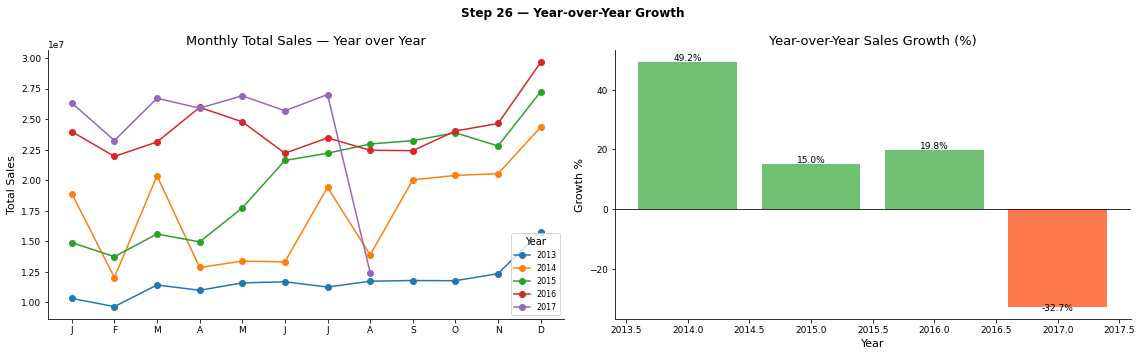

Annual Sales Growth:
date
2013      NaN
2014    49.18
2015    14.99
2016    19.83
2017   -32.72

📌 Pipeline Decision:
  → Add: year (int), trend_index = (date - 2013-01-01).days
  → trend_index captures long-term growth for LightGBM
  → Prophet handles trend component automatically via piecewise linear


In [28]:

# YoY at total level
yoy = df_train.groupby([df_train['date'].dt.year, df_train['date'].dt.month])['sales'].sum().unstack(level=0)
yoy.columns.name = 'Year'
yoy.index.name = 'Month'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# YoY monthly trend
for year in yoy.columns:
    axes[0].plot(range(1, 13), yoy[year].values, marker='o', label=str(year), linewidth=1.5)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[0].set_title('Monthly Total Sales — Year over Year')
axes[0].set_ylabel('Total Sales')
axes[0].legend(title='Year', fontsize=8)

# YoY growth rate
annual_total = df_train.groupby(df_train['date'].dt.year)['sales'].sum()
yoy_growth = annual_total.pct_change() * 100
colors = [COLOR_OK if v >= 0 else COLOR_WARN for v in yoy_growth.dropna()]
axes[1].bar(yoy_growth.dropna().index, yoy_growth.dropna().values, color=colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Year-over-Year Sales Growth (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Growth %')
for yr, val in yoy_growth.dropna().items():
    axes[1].text(yr, val + (0.5 if val >= 0 else -1.5), f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Step 26 — Year-over-Year Growth', fontweight='bold')
plt.tight_layout()
plt.show()

print("Annual Sales Growth:")
print(yoy_growth.round(2).to_string())
print(f"\n📌 Pipeline Decision:")
print(f"  → Add: year (int), trend_index = (date - 2013-01-01).days")
print(f"  → trend_index captures long-term growth for LightGBM")
print(f"  → Prophet handles trend component automatically via piecewise linear")


---
## Step 27 — Autocorrelation & Stationarity Assessment

**Why:** Autocorrelation quantifies how much past values predict future values. ACF/PACF help determine optimal lag depths. Stationarity affects whether we model levels or differences.  
**Observation:** Strong autocorrelation at lag 7 (weekly seasonality) and lag 365 (annual seasonality).


  Augmented Dickey-Fuller Test (Stationarity):
    ADF Statistic : -4.1504
    p-value       : 0.000799
    Conclusion    : STATIONARY ✅ (p < 0.05)


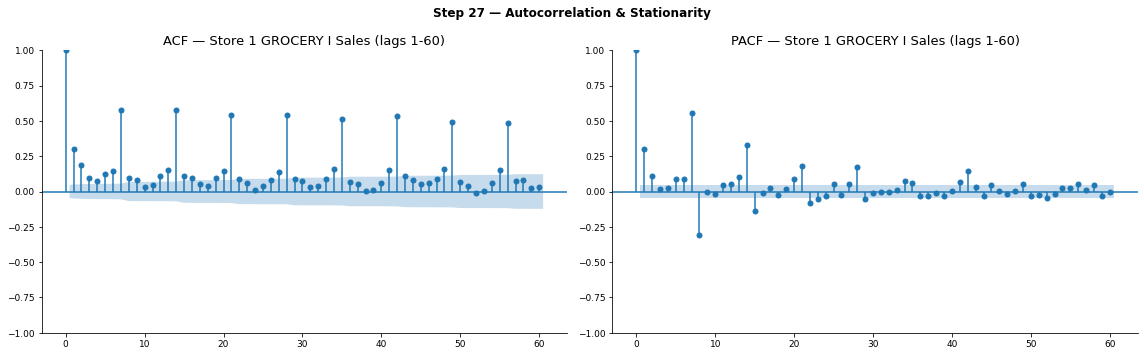


📌 Pipeline Decision:
  → Strong ACF at lag 7 → weekly seasonality confirmed
  → LightGBM lags: 7, 14, 21, 28, 35, 42 days
  → Series is stationary → model in levels
  → Prophet captures weekly + yearly seasonality automatically


In [29]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

sample_ts3 = df_train[
    (df_train['store_nbr'] == 1) & (df_train['family'] == 'GROCERY I')
].sort_values('date').set_index('date')['sales']

# ADF test
adf_result = adfuller(sample_ts3.dropna(), autolag='AIC')
print(f"  Augmented Dickey-Fuller Test (Stationarity):")
print(f"    ADF Statistic : {adf_result[0]:.4f}")
print(f"    p-value       : {adf_result[1]:.6f}")
print(f"    Conclusion    : {'STATIONARY ✅ (p < 0.05)' if adf_result[1] < 0.05 else 'NON-STATIONARY ⚠️ (p >= 0.05)'}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(sample_ts3.dropna(), lags=60, ax=axes[0], alpha=0.05,
         title='ACF — Store 1 GROCERY I Sales (lags 1-60)')
plot_pacf(sample_ts3.dropna(), lags=60, ax=axes[1], alpha=0.05, method='ywm',
          title='PACF — Store 1 GROCERY I Sales (lags 1-60)')

plt.suptitle('Step 27 — Autocorrelation & Stationarity', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Pipeline Decision:")
print(f"  → Strong ACF at lag 7 → weekly seasonality confirmed")
print(f"  → LightGBM lags: 7, 14, 21, 28, 35, 42 days")
print(f"  → Series is {'stationary' if adf_result[1] < 0.05 else 'non-stationary'} → {'model in levels' if adf_result[1] < 0.05 else 'consider differencing'}")
print(f"  → Prophet captures weekly + yearly seasonality automatically")


---
## Step 28 — EDA Summary & Pipeline Decisions

**Why:** Consolidate all findings into a single actionable reference for the ML pipeline design.


In [30]:

print("=" * 70)
print("EDA COMPLETE — FULL PIPELINE SPECIFICATION")
print("=" * 70)

summary = {
    "Dataset": {
        "Train rows"            : f"{len(df_train):,}",
        "Unique time series"    : f"{df_train['store_nbr'].nunique() * df_train['family'].nunique():,} (54 stores × 33 families)",
        "Date range (train)"    : f"{df_train['date'].min().date()} → {df_train['date'].max().date()}",
        "Forecast horizon"      : "16 days (test.csv)",
        "Missing in train"      : "NONE — clean",
        "Duplicates"            : "NONE — clean",
    },
    "Target": {
        "Column"                : "sales",
        "Transform"             : "log1p(sales) → train | expm1() → predict",
        "Zero rate"             : f"{(df_train['sales']==0).mean()*100:.1f}%",
        "Metric"                : "RMSLE",
    },
    "Imputation": {
        "oil.dcoilwtico"        : "forward-fill → backward-fill (time series)",
        "transactions"          : "median per store_nbr (has outliers)",
        "holiday flags"         : "fill 0 if date not in holidays_events",
    },
    "Features to Engineer": {
        "Calendar"              : "dow, month, year, woy, is_weekend, is_month_end",
        "Lag features"          : "sales_lag_16, 21, 28, 35, 42, 365",
        "Rolling stats"         : "rolling_mean_7/14/28, rolling_std_14 (shift=1)",
        "Promotion"             : "onpromotion, promo_lag_7, promo_rolling_14",
        "Oil"                   : "oil_price (ffilled), oil_ma_7, oil_ma_30",
        "Store metadata"        : "type, cluster, city_enc, state_enc",
        "Event flags"           : "is_national_holiday, is_regional_holiday, days_to_holiday",
        "Special events"        : "is_earthquake_period (Apr-May 2016)",
        "Target encoding"       : "store_nbr_te, family_te, store_family_te",
        "Trend"                 : "trend_index = (date - 2013-01-01).days",
    },
    "Model Plan": {
        "Primary"               : "LightGBM (tabular, handles categoricals natively)",
        "Secondary"             : "Prophet (trend + seasonality per series)",
        "Ensemble"              : "Weighted blend (Optuna-tuned weights)",
        "CV Strategy"           : "TimeSeriesSplit — NEVER shuffle time series!",
        "Validation"            : "Walk-forward: train 2013-2016, validate 2017",
    },
    "Preprocessing": {
        "Tree models (LightGBM)" : "NO scaling, NO skew correction (tree-invariant)",
        "Categorical encoding"   : "Target encoding for high-cardinality (family, store)",
        "Outliers"               : "DO NOT remove — real sales events",
        "Memory optimization"    : "Downcast dtypes (int8, float32, category)",
    }
}

for section, items in summary.items():
    print(f"\n  {'─'*60}")
    print(f"  📌 {section.upper()}")
    print(f"  {'─'*60}")
    for k, v in items.items():
        print(f"    {k:<35} : {v}")

print(f"\n{'='*70}")
print(f"✅ EDA COMPLETE — Ready for training_pipeline.py")
print(f"{'='*70}")


EDA COMPLETE — FULL PIPELINE SPECIFICATION

  ────────────────────────────────────────────────────────────
  📌 DATASET
  ────────────────────────────────────────────────────────────
    Train rows                          : 3,000,888
    Unique time series                  : 1,782 (54 stores × 33 families)
    Date range (train)                  : 2013-01-01 → 2017-08-15
    Forecast horizon                    : 16 days (test.csv)
    Missing in train                    : NONE — clean
    Duplicates                          : NONE — clean

  ────────────────────────────────────────────────────────────
  📌 TARGET
  ────────────────────────────────────────────────────────────
    Column                              : sales
    Transform                           : log1p(sales) → train | expm1() → predict
    Zero rate                           : 31.3%
    Metric                              : RMSLE

  ────────────────────────────────────────────────────────────
  📌 IMPUTATION
  ─────────

---
## 📚 References

- Kaggle Competition: [Store Sales — Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)
- Corporación Favorita — Ecuador's largest grocery chain
- Ecuador earthquake April 16, 2016 (M7.8) — caused government VAT waiver → sales spike
- WTI Oil Price crash 2015–2016 — directly impacted Ecuador's economy
- RMSLE metric: `sqrt(mean((log(1+y_pred) - log(1+y_true))^2))`

---
*Notebook by Narendra Kalam | MSc Computer Science | NASSCOM Gold Medalist*  
*Portfolio: Production-Grade ML Systems | LightGBM + Prophet + Ensemble*
